# Exploratory Data Analysis — Insurance Bundle Recommendation

> **DataQuest Hackathon · Multi-Class Classification · 10 Bundles · 60,868 Rows**

---

### Notebook Purpose

This notebook performs a comprehensive EDA to inform feature engineering decisions (20 pts rubric).

### Sections

| # | Section | Analysis |
| --- | --- | --- |
| 0–2 | Data Overview | Shape, types, missing values, duplicates |
| 3 | Target Distribution | 7,227× class imbalance visualised |
| 4 | Demographics & Financials | Income, dependents, employment, region by bundle |
| 5 | Risk Profile | Claims, cancellation, grace periods |
| 6 | Policy Preferences | Deductible tier, vehicles, riders |
| 7 | Sales & Underwriting | Channels, brokers, processing time |
| 8 | Temporal Patterns | Month, year, week trends |
| 9–10 | Distributions & Correlations | Feature histograms, full Pearson heatmap |
| 11 | High-Cardinality IDs | Broker/Employer/Region cardinality analysis |
| 12 | Train/Test Shift | Distribution comparison + KS tests |
| 13 | Key Observations | Summary table → feature engineering decisions |
| 14 | Test Set Analysis | Missing values, categoricals, numericals, temporal comparisons |
| 15 | Column Decision Matrix | Per-column drop/keep/encode/transform decisions |

---

### Target Variable Mapping

| ID | Bundle Name | Train Count | Share |
|---:|-------------|------------:|------:|
| 0  | Auto_Comprehensive | 823 | 1.4% |
| 1  | Auto_Liability_Basic | 1,625 | 2.7% |
| 2  | Basic_Health | 36,136 | 59.4% |
| 3  | Family_Comprehensive | 4,831 | 7.9% |
| 4  | Health_Dental_Vision | 13,958 | 22.9% |
| 5  | Home_Premium | 479 | 0.8% |
| 6  | Home_Standard | 719 | 1.2% |
| 7  | Premium_Health_Life | 2,286 | 3.8% |
| 8  | Renter_Basic | **6** | **0.01%** |
| 9  | Renter_Premium | **5** | **0.008%** |

## 0. Imports & Configuration

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('tab10')

# Target mapping (integers 0–9 → bundle names)
BUNDLE_MAP = {
    0: 'Auto_Comprehensive',
    1: 'Auto_Liability_Basic',
    2: 'Basic_Health',
    3: 'Family_Comprehensive',
    4: 'Health_Dental_Vision',
    5: 'Home_Premium',
    6: 'Home_Standard',
    7: 'Premium_Health_Life',
    8: 'Renter_Basic',
    9: 'Renter_Premium',
}

# Month name → integer (Policy_Start_Month is a string in the data)
MONTH_ORDER = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
MONTH_LABELS = list(MONTH_ORDER.keys())

TARGET = 'Purchased_Coverage_Bundle'

print('Setup complete.')

Setup complete.


## 1. Load Data

In [93]:
train = pd.read_csv('../Data/train.csv')
test  = pd.read_csv('../Data/test.csv')

# Readable target label
train['Bundle_Name'] = train['Purchased_Coverage_Bundle'].map(BUNDLE_MAP)

print(f'Train : {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Test  : {test.shape[0]:,} rows  × {test.shape[1]} cols')
train.head(3)

Train : 60,868 rows × 30 cols
Test  : 15,218 rows  × 28 cols


,User_ID,Policy_Cancelled_Post_Purchase,Policy_Start_Year,Policy_Start_Week,Policy_Start_Day,Grace_Period_Extensions,Previous_Policy_Duration_Months,Adult_Dependents,Child_Dependents,Infant_Dependents,...,Broker_Agency_Type,Deductible_Tier,Acquisition_Channel,Payment_Schedule,Employment_Status,Estimated_Annual_Income,Days_Since_Quote,Policy_Start_Month,Purchased_Coverage_Bundle,Bundle_Name
0,USR_000000,1,2016,50,8,0,3,2,0.0,0,...,Urban_Boutique,Tier_4_Zero_Ded,Aggregator_Site,Monthly_EFT,Employed_FullTime,26267.93,28,April,2,Basic_Health
1,USR_000001,0,2016,10,4,0,2,2,0.0,0,...,National_Corporate,Tier_1_High_Ded,Direct_Website,Monthly_EFT,Employed_FullTime,24355.18,4,July,4,Health_Dental_Vision
2,USR_000002,0,2016,9,22,1,0,1,0.0,0,...,National_Corporate,Tier_1_High_Ded,Aggregator_Site,Monthly_EFT,Employed_FullTime,13033.18,0,June,2,Basic_Health


## 2. Data Overview

In [94]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 60868 entries, 0 to 60867
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User_ID                          60868 non-null  str    
 1   Policy_Cancelled_Post_Purchase   60868 non-null  int64  
 2   Policy_Start_Year                60868 non-null  int64  
 3   Policy_Start_Week                60868 non-null  int64  
 4   Policy_Start_Day                 60868 non-null  int64  
 5   Grace_Period_Extensions          60868 non-null  int64  
 6   Previous_Policy_Duration_Months  60868 non-null  int64  
 7   Adult_Dependents                 60868 non-null  int64  
 8   Child_Dependents                 60864 non-null  float64
 9   Infant_Dependents                60868 non-null  int64  
 10  Region_Code                      60565 non-null  str    
 11  Existing_Policyholder            60868 non-null  int64  
 12  Previous_Claims_Filed        

In [95]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,60868,60868,USR_000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Policy_Cancelled_Post_Purchase,60868.0,NaN,NaN,NaN,0.277436,0.447737,0.0,0.0,0.0,1.0,1.0
Policy_Start_Year,60868.0,NaN,NaN,NaN,2016.213544,0.685983,2015.0,2016.0,2016.0,2017.0,2017.0
Policy_Start_Week,60868.0,NaN,NaN,NaN,26.86796,13.632585,1.0,16.0,27.0,37.0,53.0
Policy_Start_Day,60868.0,NaN,NaN,NaN,15.839341,8.853256,1.0,8.0,16.0,24.0,31.0
Grace_Period_Extensions,60868.0,NaN,NaN,NaN,1.019698,1.040345,0.0,0.0,1.0,2.0,19.0
Previous_Policy_Duration_Months,60868.0,NaN,NaN,NaN,2.659066,2.075896,0.0,1.0,2.0,4.0,50.0
Adult_Dependents,60868.0,NaN,NaN,NaN,1.889499,0.609059,0.0,2.0,2.0,2.0,55.0
Child_Dependents,60864.0,NaN,NaN,NaN,0.150516,0.478308,0.0,0.0,0.0,0.0,10.0
Infant_Dependents,60868.0,NaN,NaN,NaN,0.011287,0.113003,0.0,0.0,0.0,0.0,9.0


### 2.1 Missing Values

In [96]:
def missing_summary(df, label='Train'):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if miss.empty:
        print(f'{label}: No missing values.')
        return
    miss_pct = (miss / len(df) * 100).round(2)
    out = pd.DataFrame({'Missing': miss, 'Pct (%)': miss_pct})
    print(f'\n{label} — {len(miss)} columns with missing values:')
    display(out)

missing_summary(train, 'Train')
missing_summary(test,  'Test')


Train — 6 columns with missing values:


,Missing,Pct (%)
Employer_ID,57396,94.30
Broker_ID,8331,13.69
Acquisition_Channel,666,1.09
Deductible_Tier,314,0.52
Region_Code,303,0.50
Child_Dependents,4,0.01



Test — 5 columns with missing values:


,Missing,Pct (%)
Employer_ID,14350,94.30
Broker_ID,2077,13.65
Acquisition_Channel,143,0.94
Deductible_Tier,95,0.62
Region_Code,89,0.58


### 2.2 Duplicate Rows

In [97]:
print(f'Train duplicate rows : {train.duplicated().sum()}')
print(f'Test  duplicate rows : {test.duplicated().sum()}')

Train duplicate rows : 0
Test  duplicate rows : 0


## 3. Target Distribution

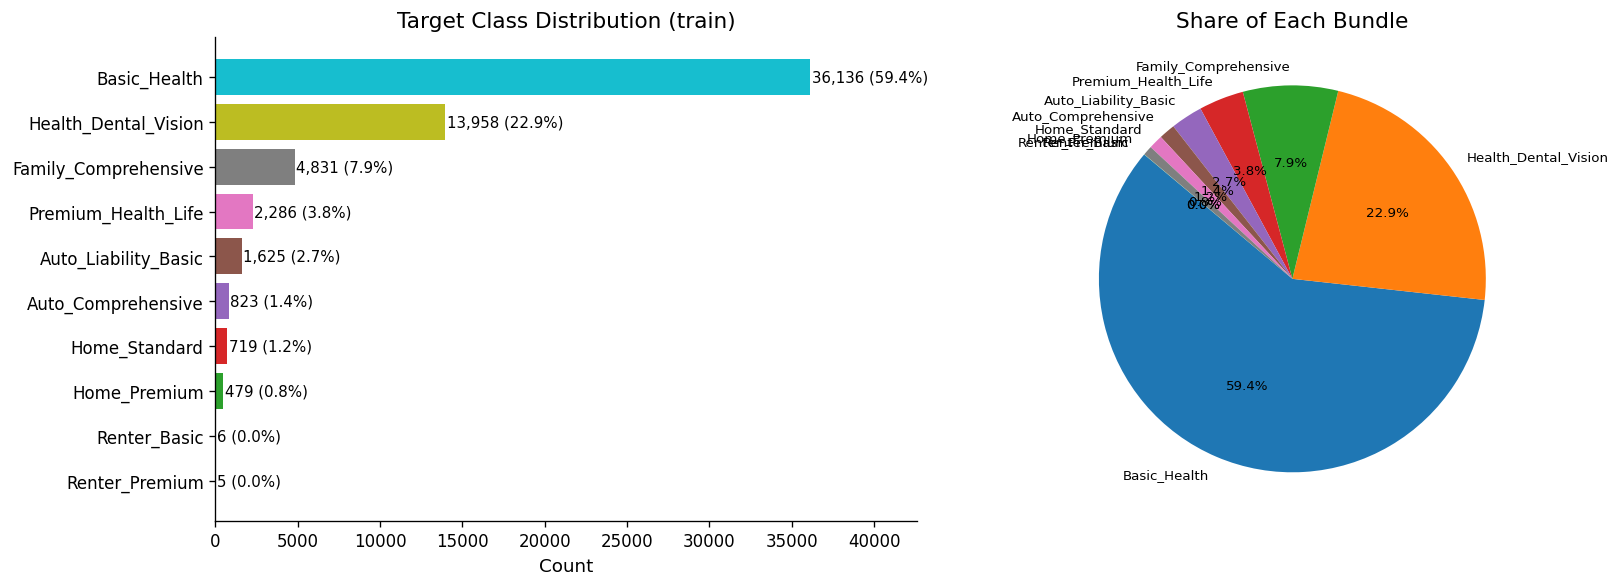

In [ ]:
counts = train['Bundle_Name'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('tab10', n_colors=10)
axes[0].barh(counts.index, counts.values, color=colors)
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0].text(val + 80, i, f'{val:,} ({val/len(train)*100:.1f}%)', va='center', fontsize=9)
axes[0].set_xlabel('Count')
axes[0].set_title('Target Class Distribution (train)')
axes[0].set_xlim(0, counts.max() * 1.18)

# Pie chart
axes[1].pie(
    counts.values[::-1],
    labels=counts.index[::-1],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 8},
)
axes[1].set_title('Share of Each Bundle')

plt.tight_layout()
plt.savefig('assets/target_distribution.png', bbox_inches='tight')
plt.show()

## 4. Demographics & Financials

### 4.1 Income by Bundle

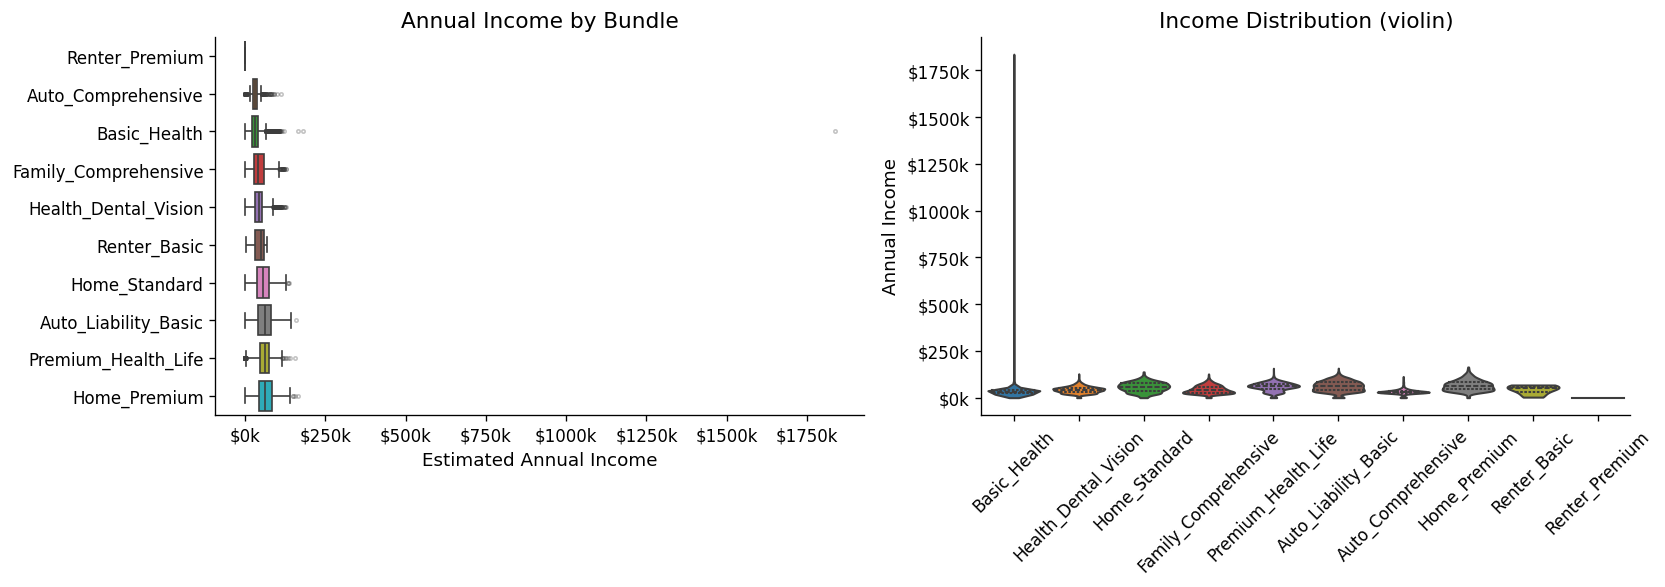

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
order = train.groupby('Bundle_Name')['Estimated_Annual_Income'].median().sort_values().index
sns.boxplot(
    data=train, x='Estimated_Annual_Income', y='Bundle_Name',
    order=order, palette='tab10', ax=axes[0],
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[0].set_title('Annual Income by Bundle')
axes[0].set_xlabel('Estimated Annual Income')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# Violin
sns.violinplot(
    data=train, x='Bundle_Name', y='Estimated_Annual_Income',
    palette='tab10', ax=axes[1], inner='quartile', cut=0
)
axes[1].set_title('Income Distribution (violin)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Annual Income')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.savefig('assets/income_by_bundle.png', bbox_inches='tight')
plt.show()

### 4.2 Dependents

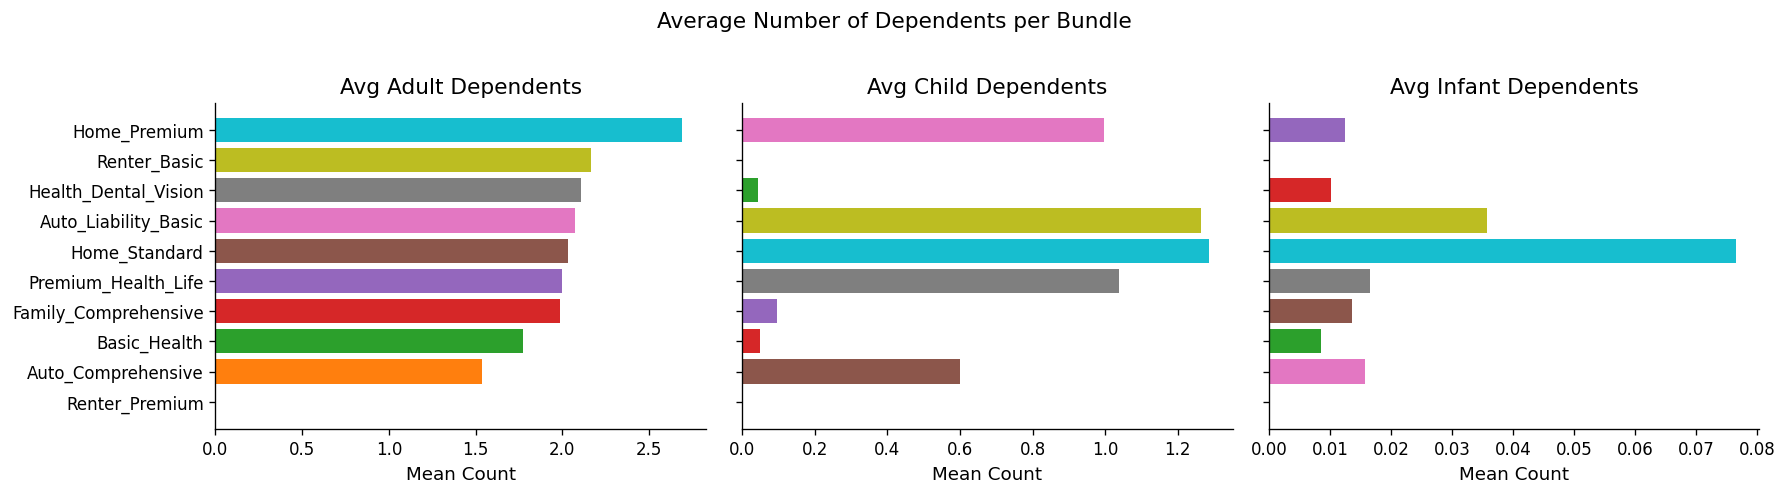

In [ ]:
dep_cols = ['Adult_Dependents', 'Child_Dependents', 'Infant_Dependents']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, dep_cols):
    means = train.groupby('Bundle_Name')[col].mean().sort_values()
    ax.barh(means.index, means.values, color=sns.color_palette('tab10', n_colors=10))
    ax.set_title(f'Avg {col.replace("_", " ")}')
    ax.set_xlabel('Mean Count')
    ax.set_ylabel('')

plt.suptitle('Average Number of Dependents per Bundle', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('assets/dependents_by_bundle.png', bbox_inches='tight')
plt.show()

### 4.3 Employment Status & Region

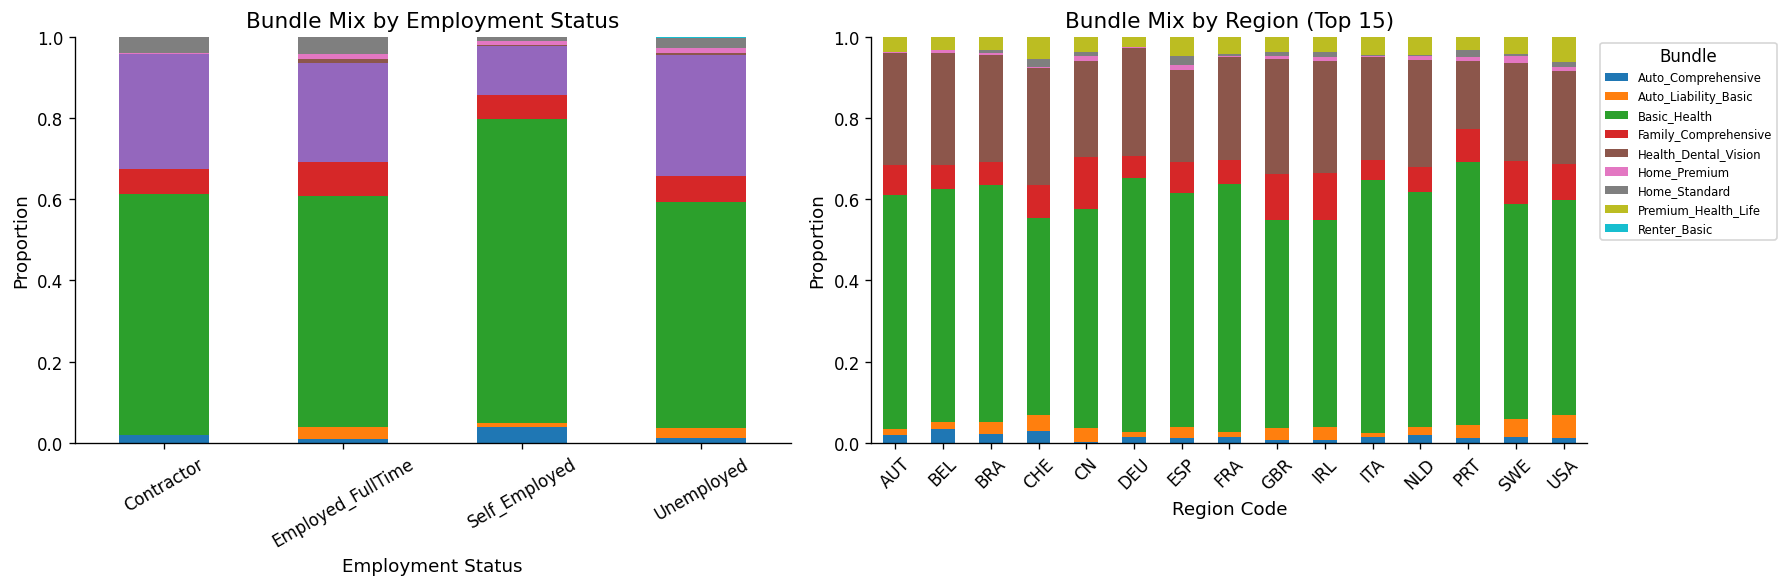

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Employment Status — stacked bar (normalized)
emp_pivot = (
    train.groupby(['Employment_Status', 'Bundle_Name'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
emp_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', legend=False)
axes[0].set_title('Bundle Mix by Employment Status')
axes[0].set_xlabel('Employment Status')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=30)

# Region Code — count per bundle (top 15 regions)
top_regions = train['Region_Code'].value_counts().head(15).index
region_data = train[train['Region_Code'].isin(top_regions)]
region_pivot = (
    region_data.groupby(['Region_Code', 'Bundle_Name'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
region_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', legend=True)
axes[1].set_title('Bundle Mix by Region (Top 15)')
axes[1].set_xlabel('Region Code')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, title='Bundle')

plt.tight_layout()
plt.savefig('assets/employment_region.png', bbox_inches='tight')
plt.show()

## 5. Customer History & Risk Profile

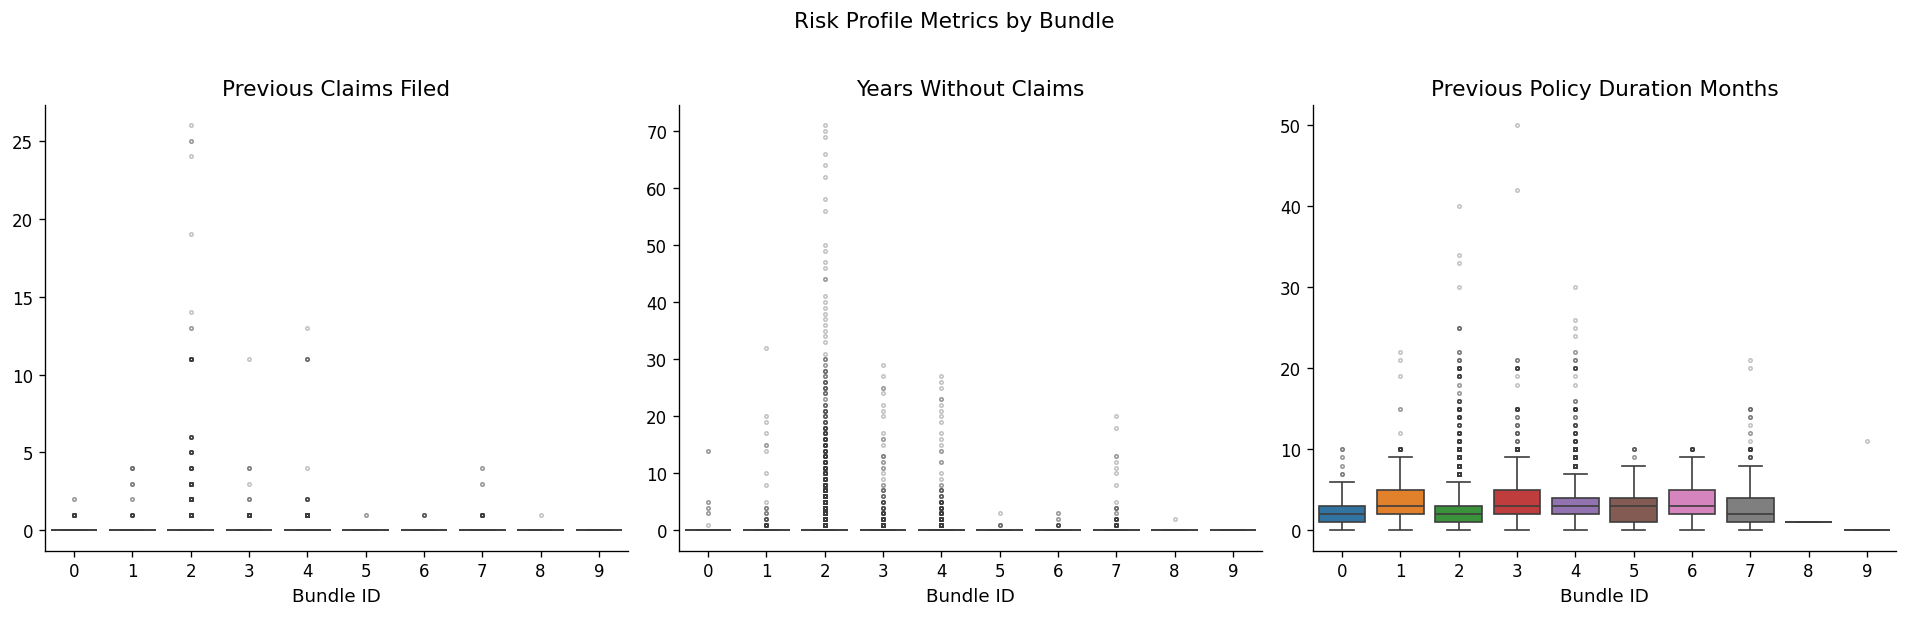

In [ ]:
risk_cols = [
    'Previous_Claims_Filed',
    'Years_Without_Claims',
    'Previous_Policy_Duration_Months',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, risk_cols):
    sns.boxplot(
        data=train, x='Purchased_Coverage_Bundle', y=col,
        palette='tab10', ax=ax,
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Bundle ID')
    ax.set_ylabel('')

plt.suptitle('Risk Profile Metrics by Bundle', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('assets/risk_profile.png', bbox_inches='tight')
plt.show()

### 5.1 Binary Risk Flags

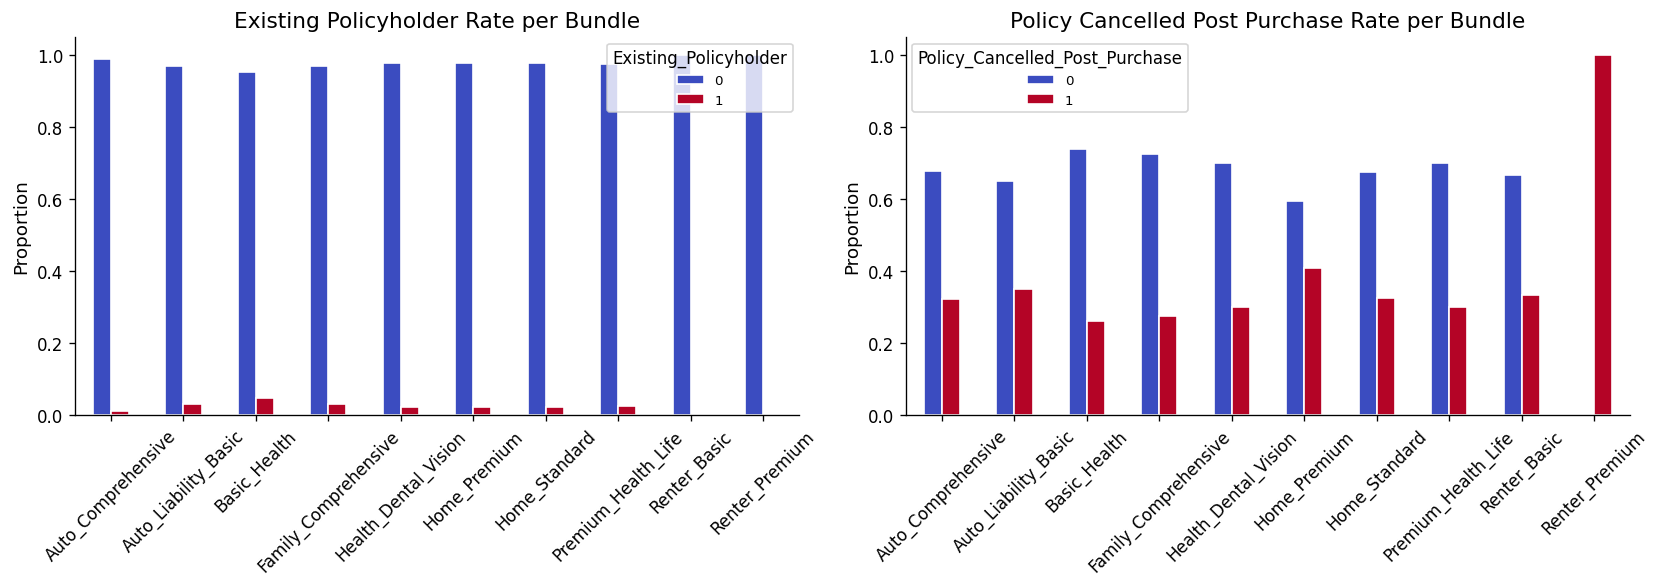

In [ ]:
binary_cols = ['Existing_Policyholder', 'Policy_Cancelled_Post_Purchase']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, binary_cols):
    pivot = (
        train.groupby(['Bundle_Name', col])
        .size().unstack(fill_value=0)
        .apply(lambda r: r / r.sum(), axis=1)
    )
    pivot.plot(kind='bar', ax=ax, colormap='coolwarm', edgecolor='white')
    ax.set_title(f'{col.replace("_", " ")} Rate per Bundle')
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title=col, fontsize=8)

plt.tight_layout()
plt.savefig('assets/binary_risk_flags.png', bbox_inches='tight')
plt.show()

## 6. Policy Details & Preferences

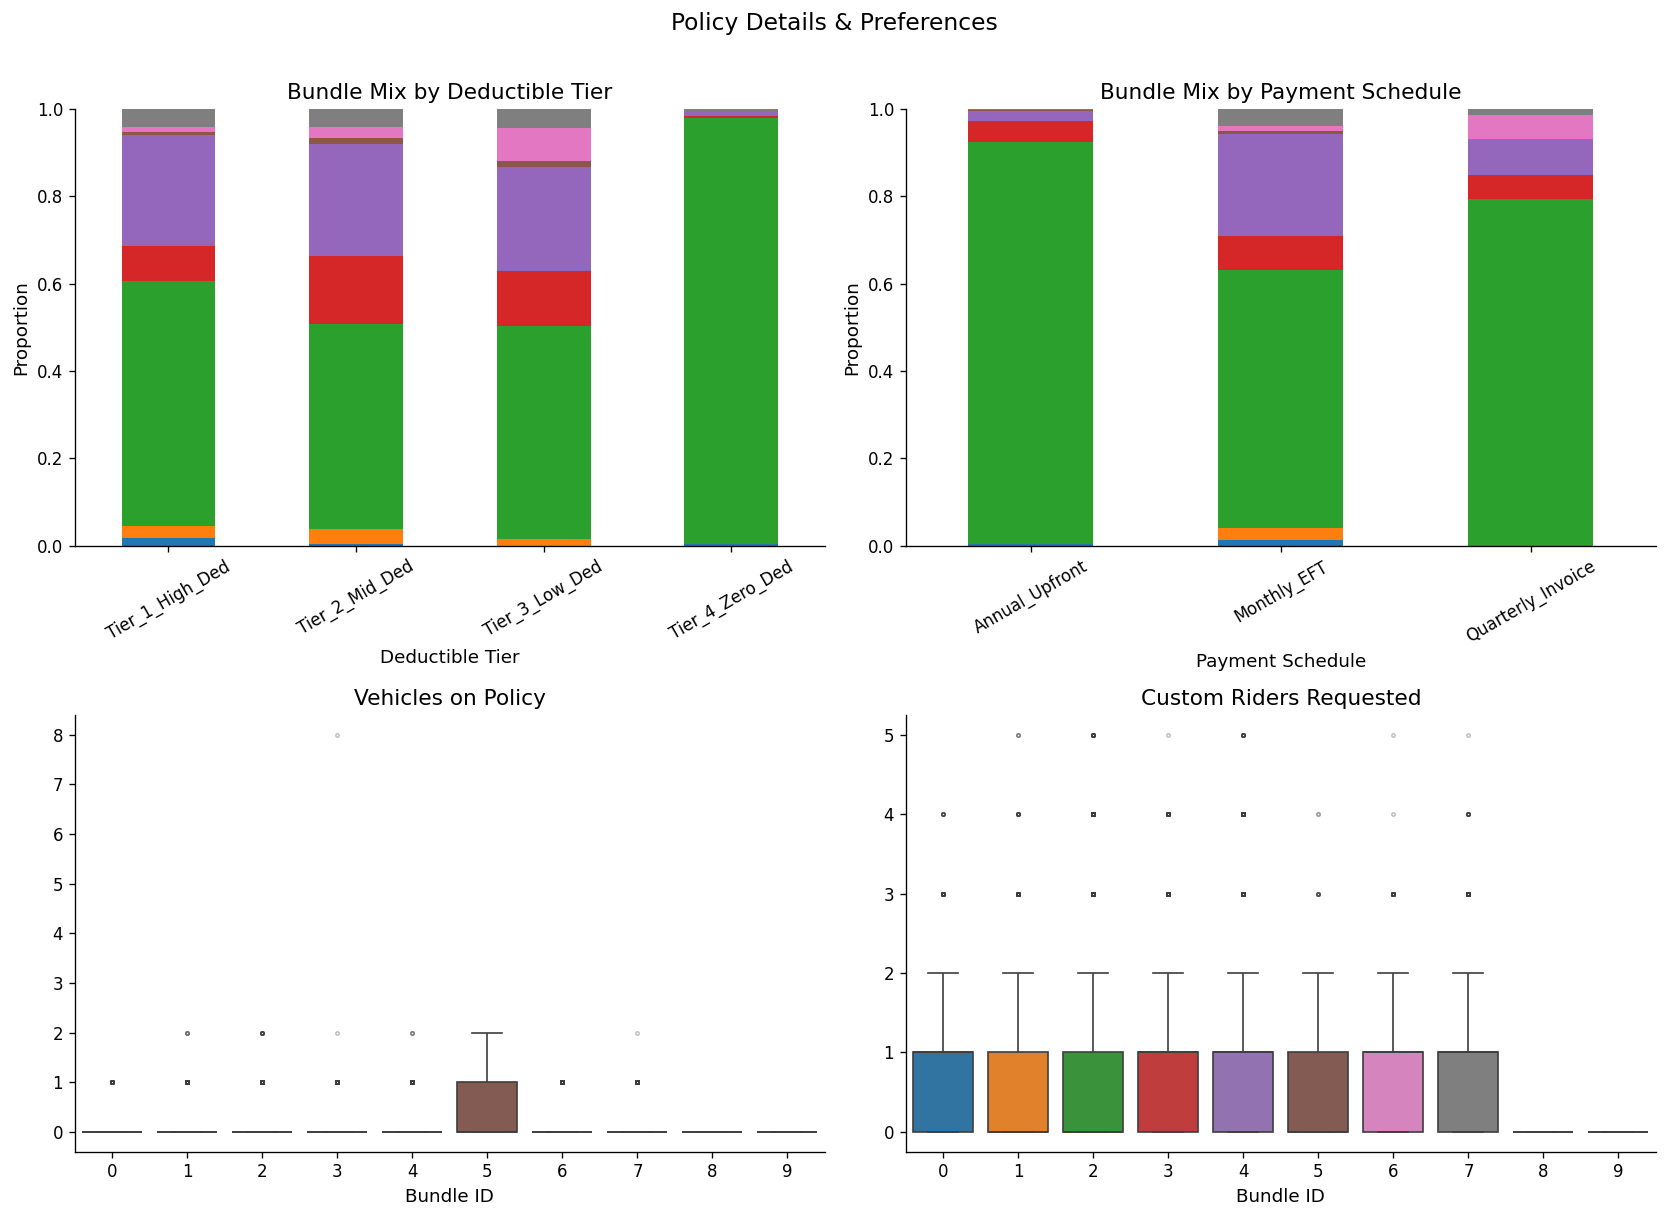

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

policy_cat = ['Deductible_Tier', 'Payment_Schedule']
policy_num = ['Vehicles_on_Policy', 'Custom_Riders_Requested']

# Categorical — stacked bar
for ax, col in zip(axes[0], policy_cat):
    pivot = (
        train.groupby([col, 'Bundle_Name'])
        .size().unstack(fill_value=0)
        .apply(lambda r: r / r.sum(), axis=1)
    )
    pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', legend=False)
    ax.set_title(f'Bundle Mix by {col.replace("_", " ")}')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=30)

# Numeric — box
for ax, col in zip(axes[1], policy_num):
    sns.boxplot(
        data=train, x='Purchased_Coverage_Bundle', y=col,
        palette='tab10', ax=ax,
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Bundle ID')
    ax.set_ylabel('')

plt.suptitle('Policy Details & Preferences', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('assets/policy_details.png', bbox_inches='tight')
plt.show()

## 7. Sales & Underwriting Process

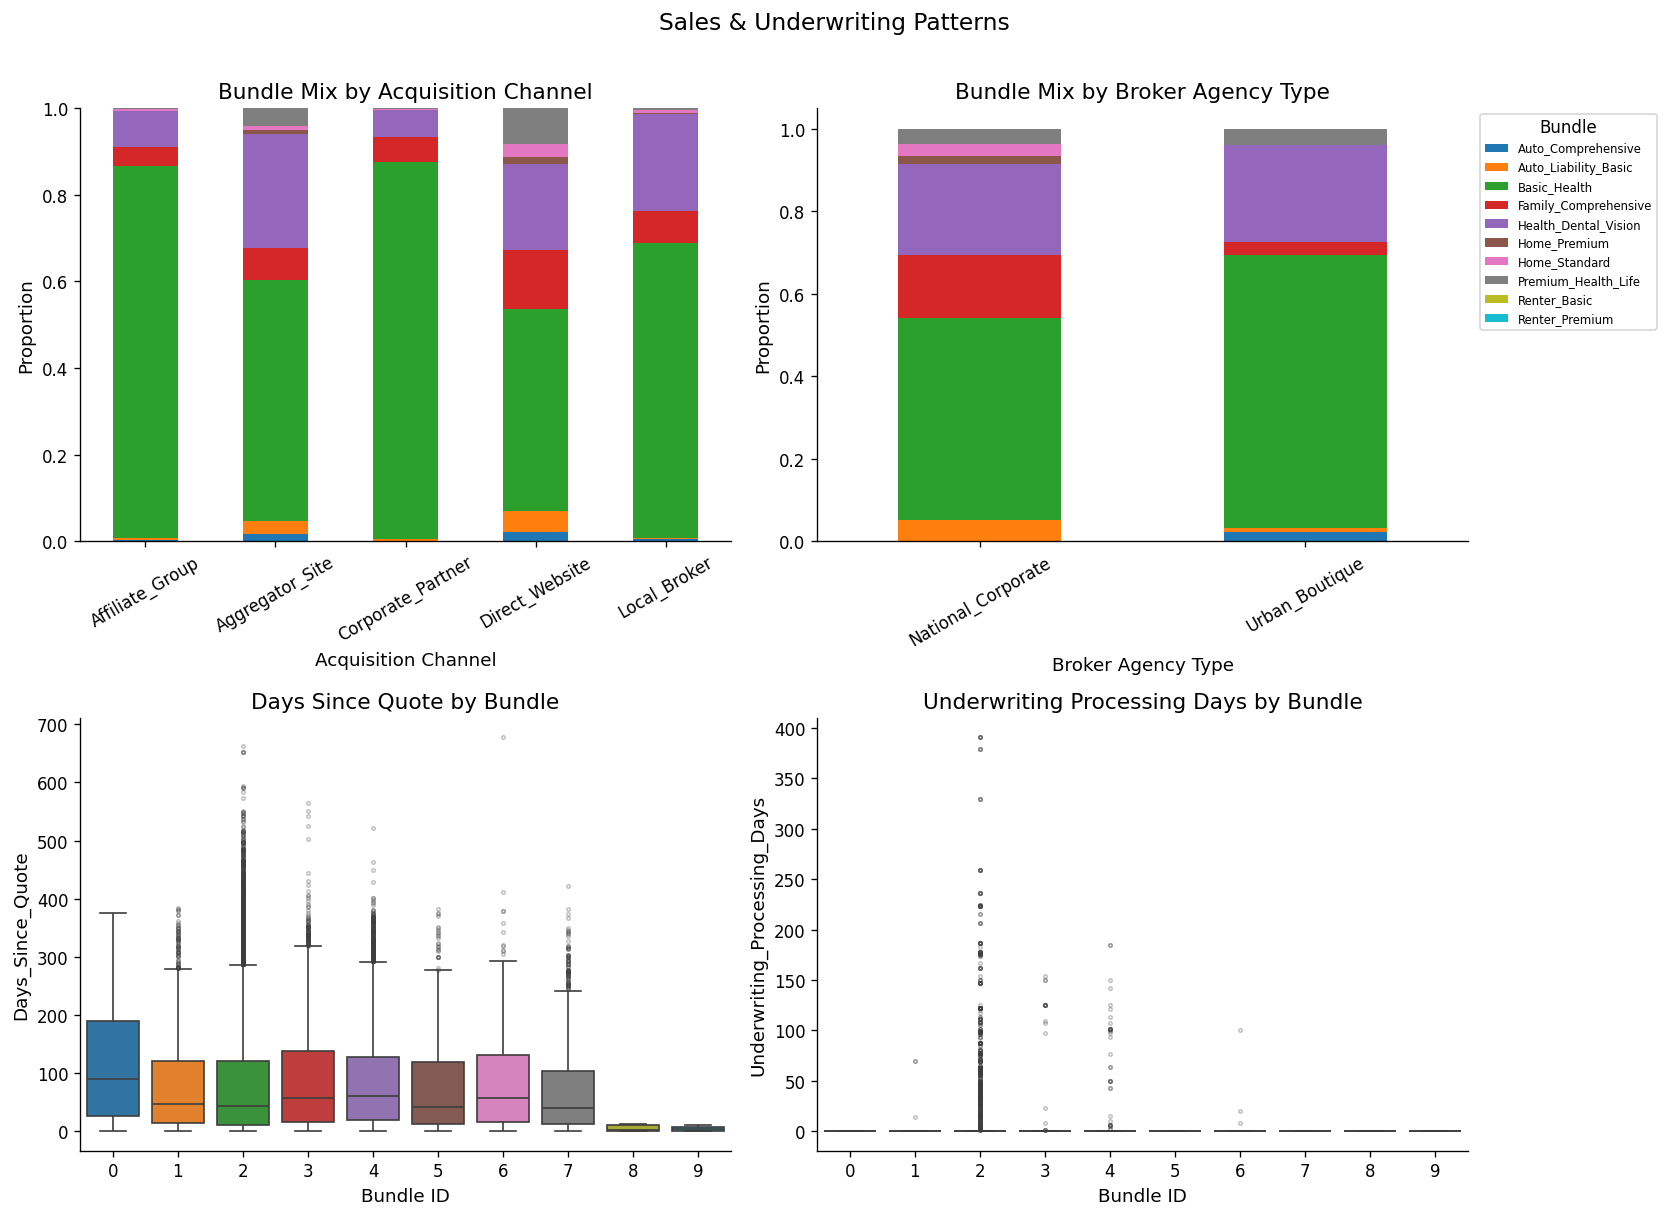

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Acquisition Channel
acq_pivot = (
    train.groupby(['Acquisition_Channel', 'Bundle_Name'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
acq_pivot.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='tab10', legend=False)
axes[0, 0].set_title('Bundle Mix by Acquisition Channel')
axes[0, 0].set_xlabel('Acquisition Channel')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].tick_params(axis='x', rotation=30)

# Broker Agency Type
broker_pivot = (
    train.groupby(['Broker_Agency_Type', 'Bundle_Name'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
broker_pivot.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='tab10', legend=True)
axes[0, 1].set_title('Bundle Mix by Broker Agency Type')
axes[0, 1].set_xlabel('Broker Agency Type')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, title='Bundle')

# Days Since Quote
sns.boxplot(
    data=train, x='Purchased_Coverage_Bundle', y='Days_Since_Quote',
    palette='tab10', ax=axes[1, 0],
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1, 0].set_title('Days Since Quote by Bundle')
axes[1, 0].set_xlabel('Bundle ID')

# Underwriting Processing Days
sns.boxplot(
    data=train, x='Purchased_Coverage_Bundle', y='Underwriting_Processing_Days',
    palette='tab10', ax=axes[1, 1],
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1, 1].set_title('Underwriting Processing Days by Bundle')
axes[1, 1].set_xlabel('Bundle ID')

plt.suptitle('Sales & Underwriting Patterns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('assets/sales_underwriting.png', bbox_inches='tight')
plt.show()

## 8. Temporal Patterns

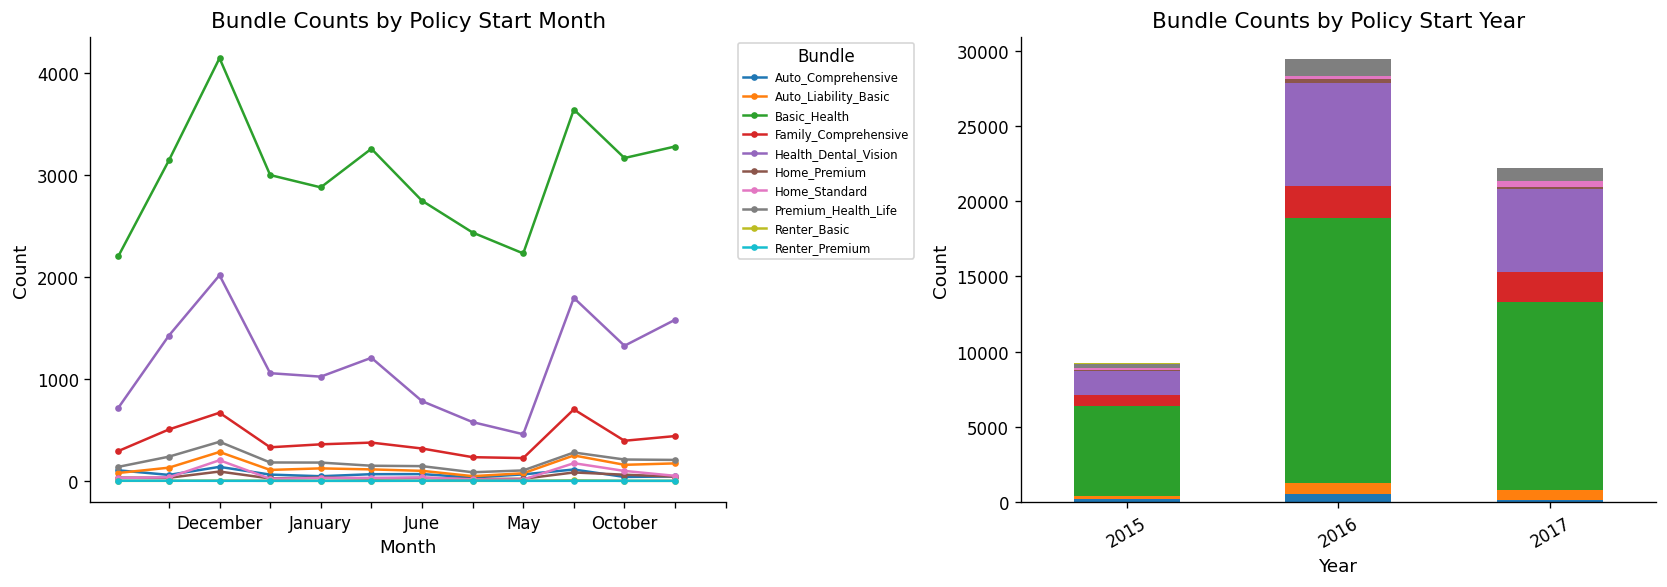

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bundle counts by month
month_pivot = (
    train.groupby(['Policy_Start_Month', 'Bundle_Name'])
    .size().unstack(fill_value=0)
)
month_pivot.plot(kind='line', ax=axes[0], colormap='tab10', marker='o', markersize=3)
axes[0].set_title('Bundle Counts by Policy Start Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1, 13))
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, title='Bundle')

# Bundle counts by year
year_pivot = (
    train.groupby(['Policy_Start_Year', 'Bundle_Name'])
    .size().unstack(fill_value=0)
)
year_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', legend=False)
axes[1].set_title('Bundle Counts by Policy Start Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('assets/temporal_patterns.png', bbox_inches='tight')
plt.show()

## 9. Numerical Feature Distributions

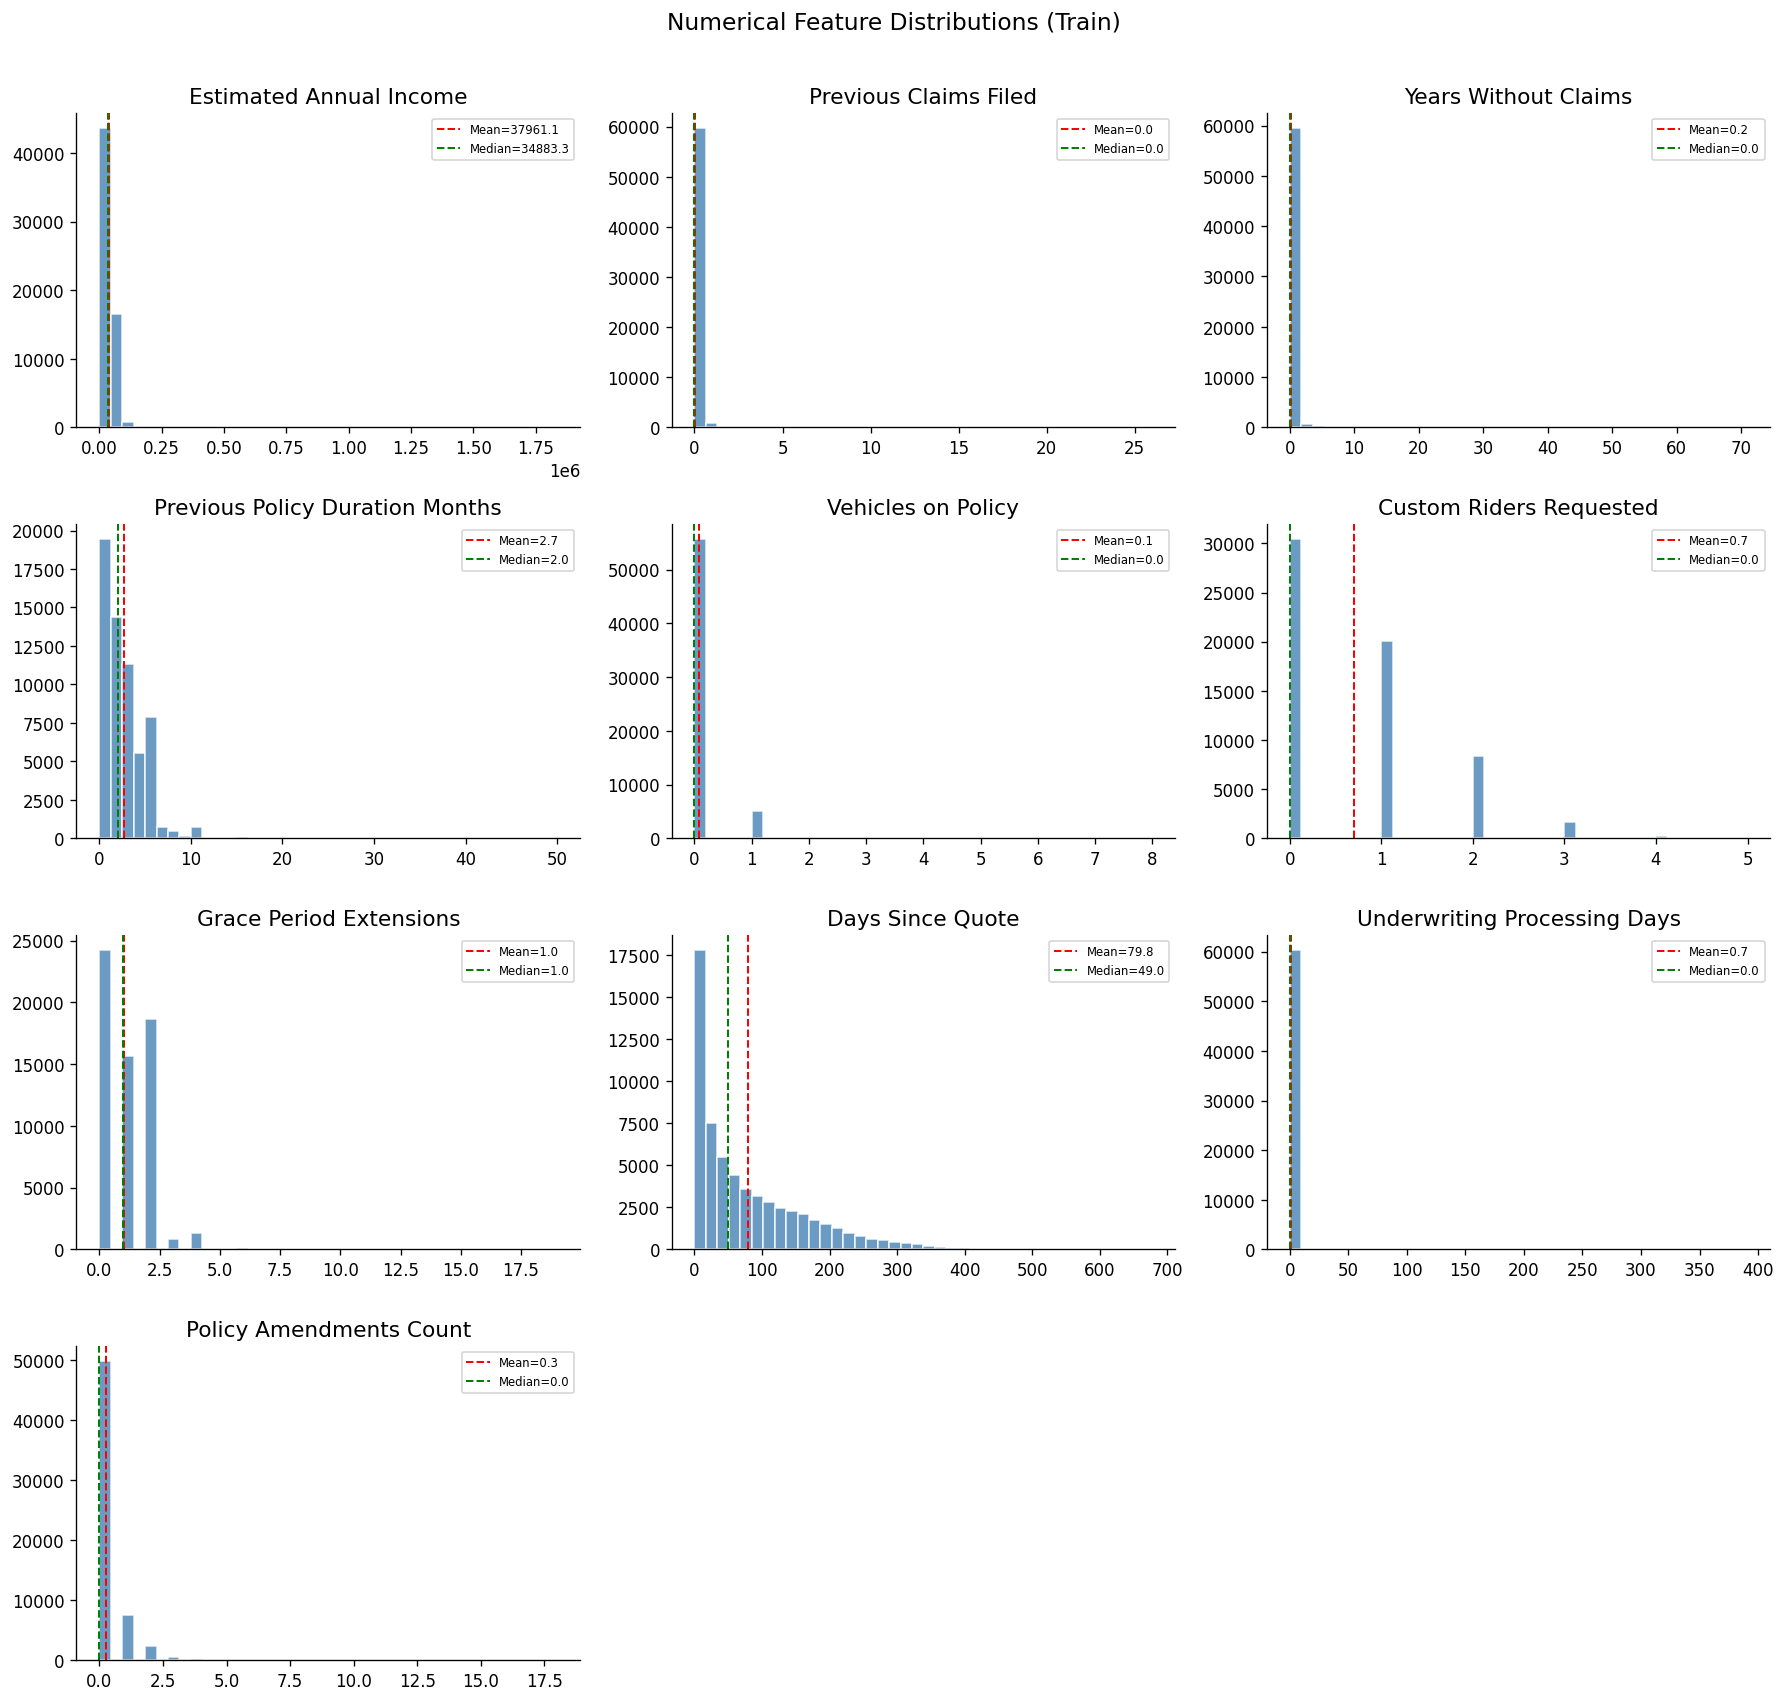

In [ ]:
num_cols = [
    'Estimated_Annual_Income', 'Previous_Claims_Filed', 'Years_Without_Claims',
    'Previous_Policy_Duration_Months', 'Vehicles_on_Policy', 'Custom_Riders_Requested',
    'Grace_Period_Extensions', 'Days_Since_Quote', 'Underwriting_Processing_Days',
    'Policy_Amendments_Count',
]

nrows = (len(num_cols) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(train[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(train[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={train[col].mean():.1f}')
    ax.axvline(train[col].median(), color='green', linestyle='--', linewidth=1.2, label=f'Median={train[col].median():.1f}')
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=7)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle('Numerical Feature Distributions (Train)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('assets/feature_distributions.png', bbox_inches='tight')
plt.show()

## 10. Correlation Heatmap

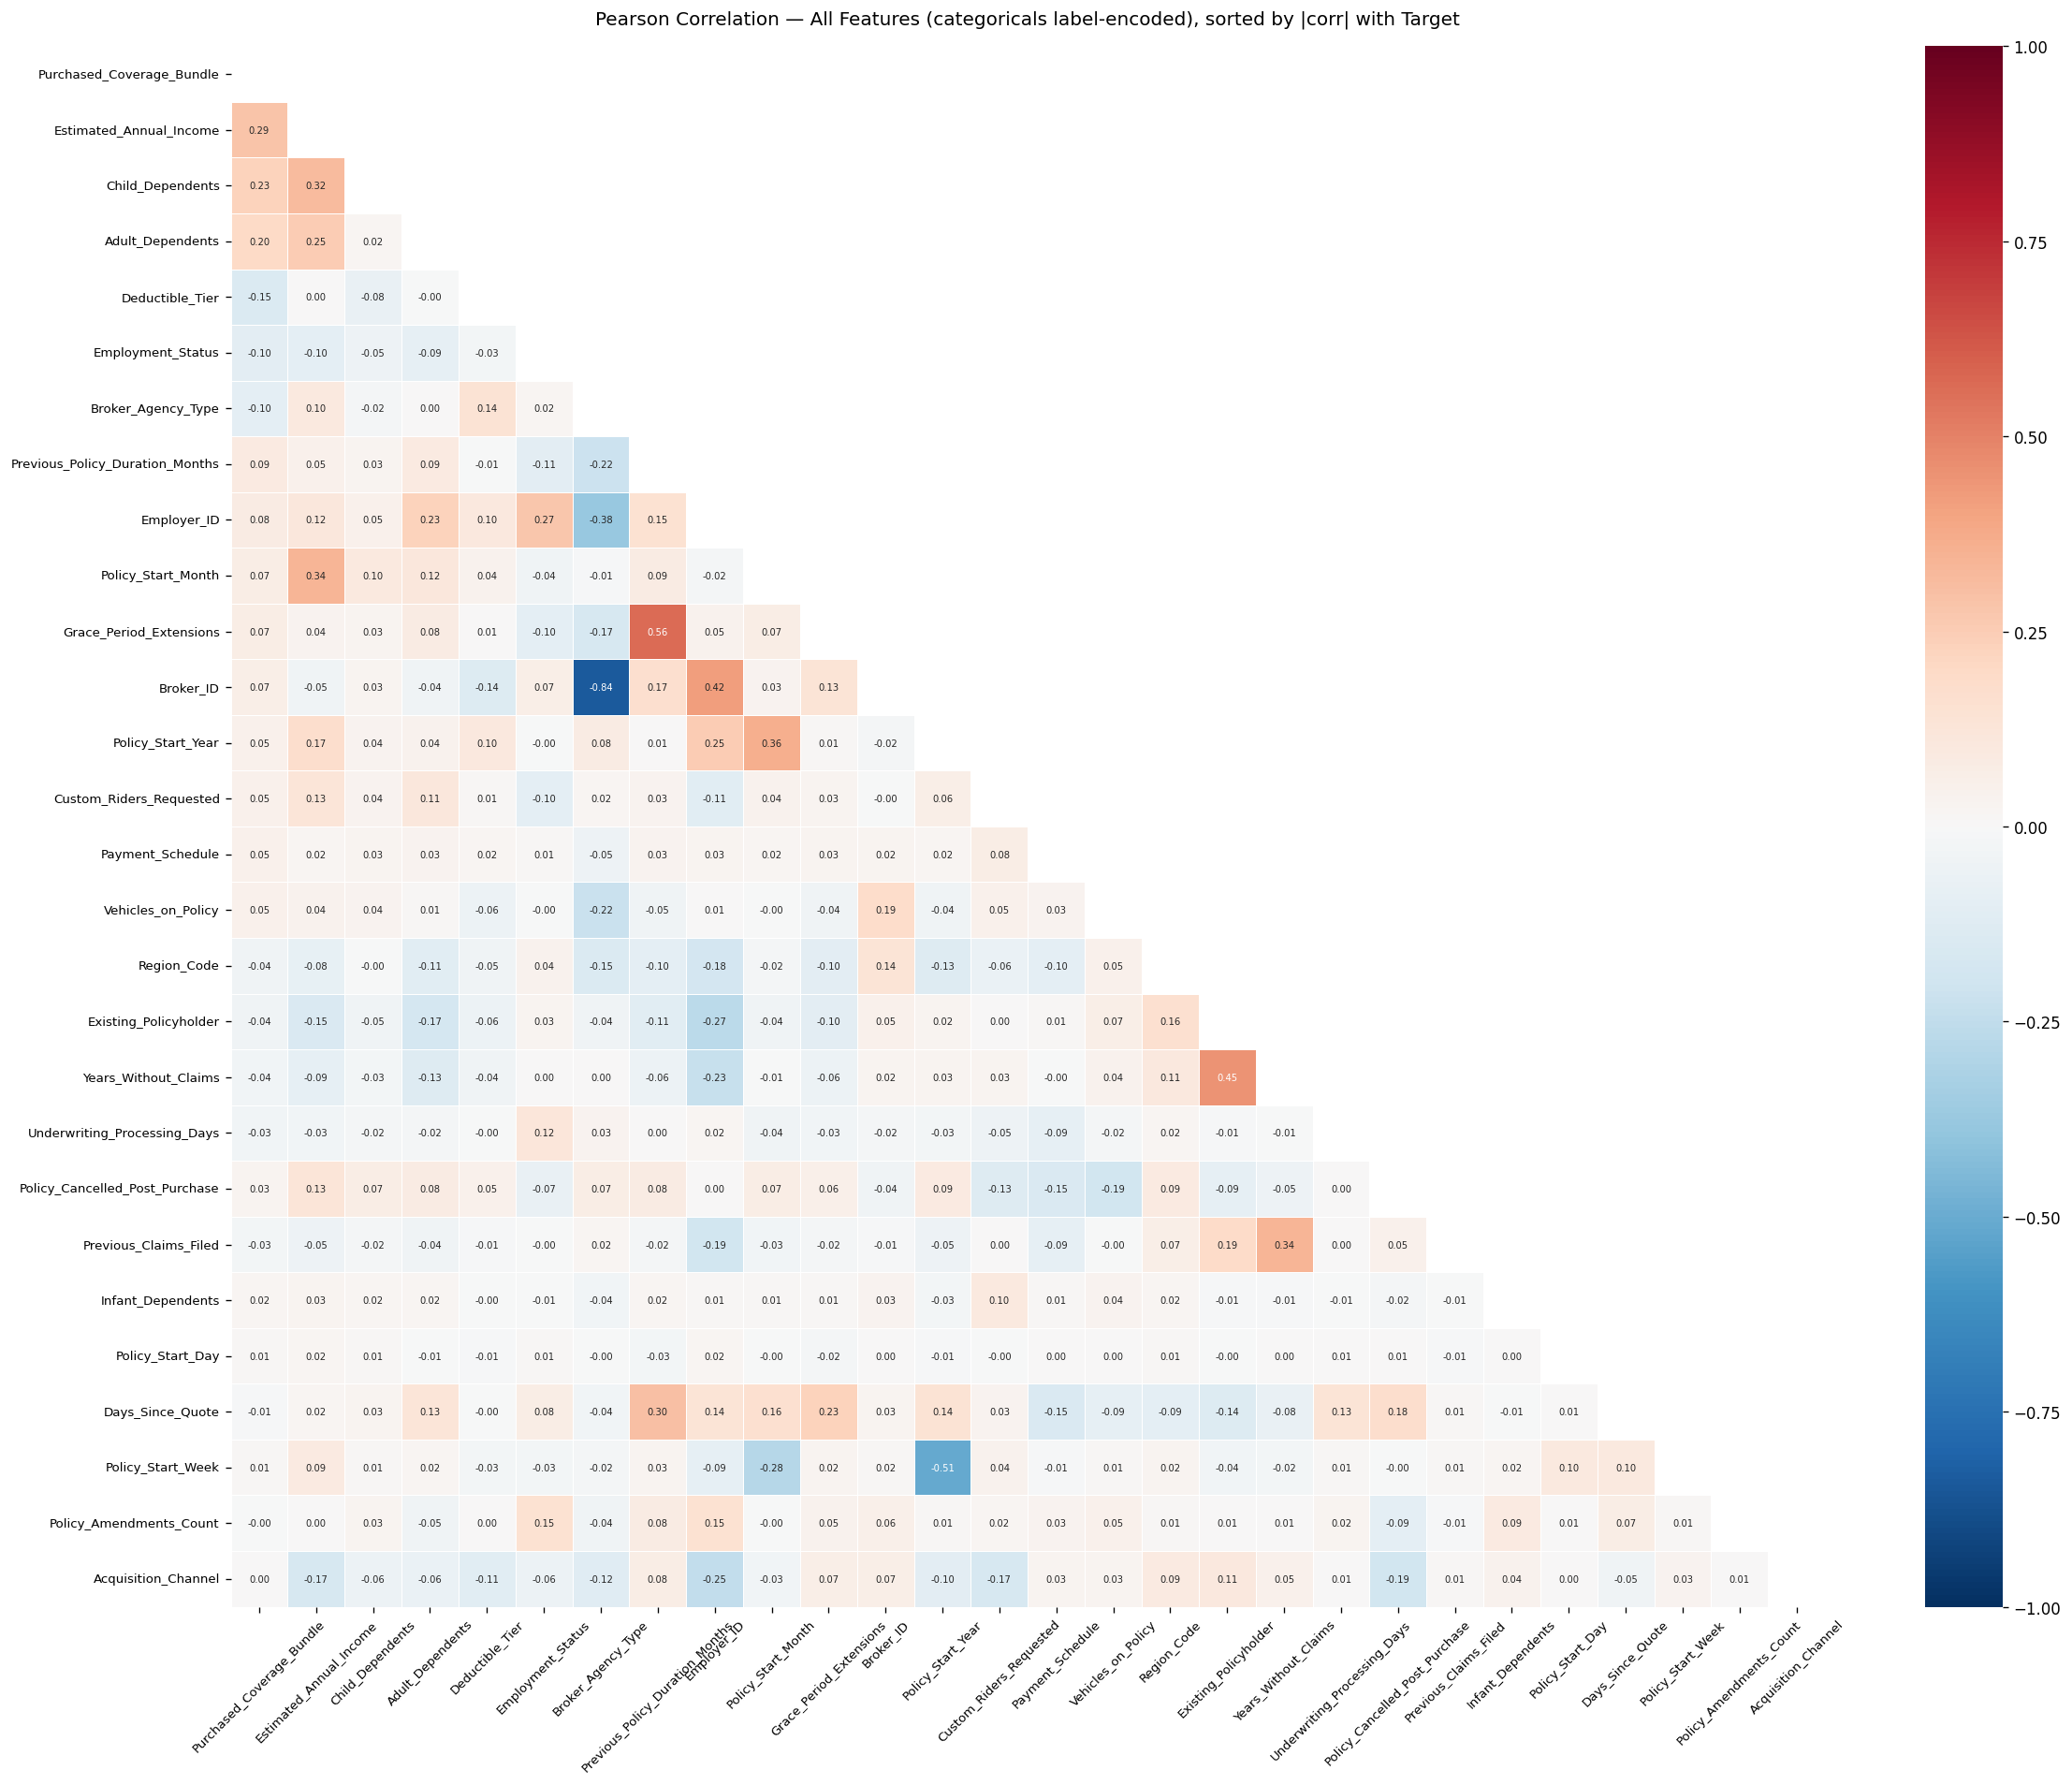


Top 15 features by |correlation| with Purchased_Coverage_Bundle:
Estimated_Annual_Income            0.287
Child_Dependents                   0.230
Adult_Dependents                   0.196
Deductible_Tier                    0.146
Employment_Status                  0.104
Broker_Agency_Type                 0.096
Previous_Policy_Duration_Months    0.094
Employer_ID                        0.083
Policy_Start_Month                 0.073
Grace_Period_Extensions            0.073
Broker_ID                          0.069
Policy_Start_Year                  0.054
Custom_Riders_Requested            0.050
Payment_Schedule                   0.048
Vehicles_on_Policy                 0.048


In [ ]:
from sklearn.preprocessing import LabelEncoder

# ── Build a fully-numeric copy of train ───────────────────────────────────
corr_df = train.drop(columns=['User_ID', 'Bundle_Name']).copy()

# Convert Policy_Start_Month string → integer
corr_df['Policy_Start_Month'] = corr_df['Policy_Start_Month'].map(MONTH_ORDER)

# Label-encode remaining string columns
cat_cols = corr_df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    corr_df[col] = corr_df[col].astype(str)   # NaN → "nan" string, handled below
    corr_df[col] = le.fit_transform(corr_df[col])

# Pearson correlation on all columns
corr = corr_df.corr()

# Sort columns by absolute correlation with target for readability
target_corr = corr[TARGET].abs().sort_values(ascending=False)
col_order = target_corr.index.tolist()
corr = corr.loc[col_order, col_order]

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={'size': 6},
)
ax.set_title('Pearson Correlation — All Features (categoricals label-encoded), sorted by |corr| with Target',
             fontsize=12, pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('assets/correlation_heatmap_full.png', bbox_inches='tight')
plt.show()

# Top correlations with target
print('\nTop 15 features by |correlation| with Purchased_Coverage_Bundle:')
print(target_corr.drop(TARGET).head(15).round(3).to_string())

## 11. Cardinality of High-ID Columns

In [109]:
id_cols = ['Broker_ID', 'Employer_ID', 'Region_Code']

for col in id_cols:
    n_unique = train[col].nunique()
    top5 = train[col].value_counts().head(5)
    print(f'{col}: {n_unique} unique values')
    print(top5.to_string(), '\n')

Broker_ID: 315 unique values
Broker_ID
9.0      20065
240.0     9317
14.0      2368
7.0       2307
250.0     2076 

Employer_ID: 309 unique values
Employer_ID
40.0     547
223.0    334
45.0     170
153.0    151
281.0     88 

Region_Code: 166 unique values
Region_Code
PRT    18863
GBR     7417
FRA     6172
ESP     5067
DEU     3697 



In [110]:
# Target encoding preview: mean bundle ID per broker (top 20 brokers by volume)
top_brokers = train['Broker_ID'].value_counts().head(20).index
broker_stats = (
    train[train['Broker_ID'].isin(top_brokers)]
    .groupby('Broker_ID')['Purchased_Coverage_Bundle']
    .agg(['mean', 'std', 'count'])
    .sort_values('count', ascending=False)
)
broker_stats.columns = ['Mean Bundle', 'Std Bundle', 'Count']
broker_stats

,Mean Bundle,Std Bundle,Count
Broker_ID,,,
9.0,2.833541,1.406758,20065
240.0,2.726199,1.137901,9317
14.0,2.622889,1.321276,2368
7.0,2.660165,1.308384,2307
250.0,3.821773,1.983311,2076
241.0,3.501664,1.850017,1202
28.0,2.423228,0.884465,1016
8.0,2.604899,1.204300,939
1.0,2.001233,0.207866,811


## 12. Train / Test Feature Distribution Comparison
Check for distribution shift between train and test sets.

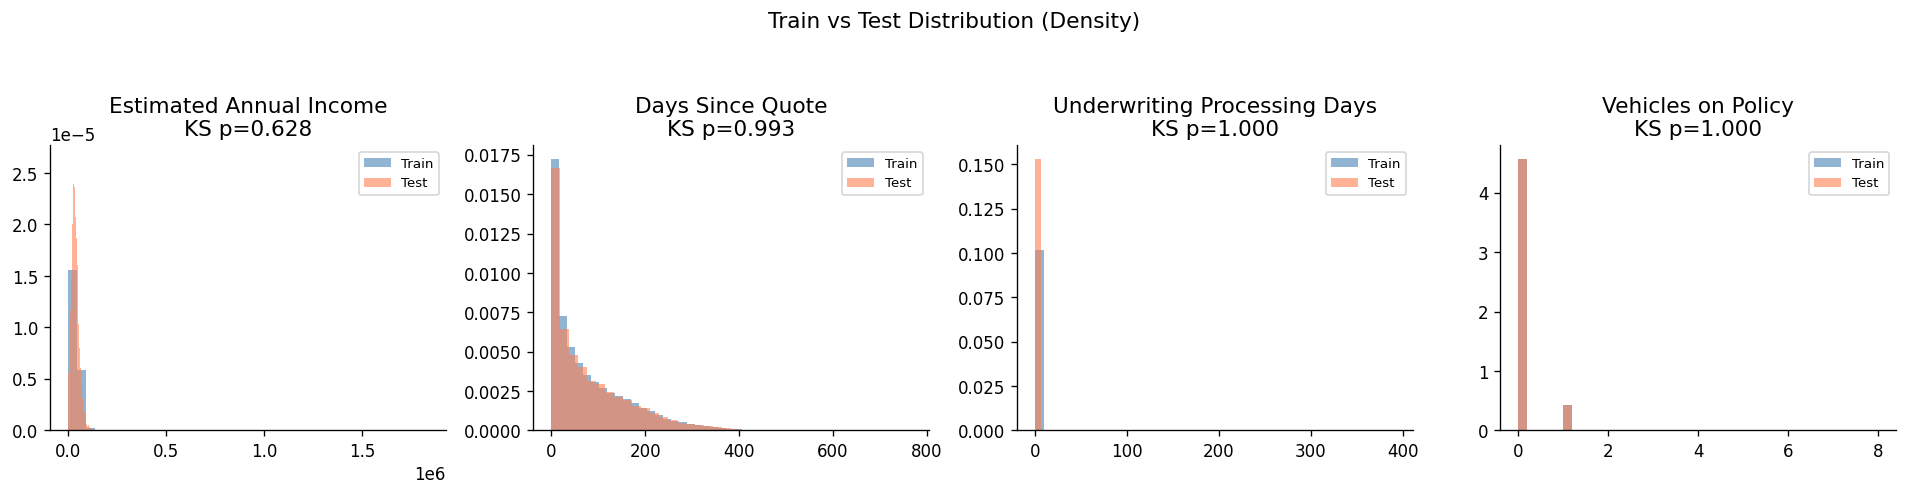

In [ ]:
compare_cols = [
    'Estimated_Annual_Income', 'Days_Since_Quote',
    'Underwriting_Processing_Days', 'Vehicles_on_Policy',
]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(16, 4))

for ax, col in zip(axes, compare_cols):
    ax.hist(train[col].dropna(), bins=40, alpha=0.6, label='Train', density=True, color='steelblue')
    ax.hist(test[col].dropna(),  bins=40, alpha=0.6, label='Test',  density=True, color='coral')
    # KS test
    ks_stat, ks_p = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    ax.set_title(f'{col.replace("_", " ")}\nKS p={ks_p:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Train vs Test Distribution (Density)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('assets/train_test_shift.png', bbox_inches='tight')
plt.show()

## 13. Key EDA Observations

> Fill this in after running the notebook.

| # | Observation | Feature Engineering Idea |
|---|-------------|---------------------------|
| 1 | Income varies strongly by bundle | Bin income into quartiles |
| 2 | Broker_ID / Employer_ID are high-cardinality | Target-encode vs. frequency-encode |
| 3 | Temporal columns (month/week/day) may show seasonality | Cyclical encoding (sin/cos) |
| 4 | Total dependents = sum of adult + child + infant | Create `Total_Dependents` feature |
| 5 | `Grace_Period_Extensions` + `Policy_Cancelled_Post_Purchase` signal financial stress | Create a `Risk_Score` composite |
| 6 | `Days_Since_Quote` × `Policy_Amendments_Count` may signal indecision | Interaction term |

## 14. Test Set Visualization

The test set has no target column. These charts show the feature distributions
of the test population and how they compare to train — essential for spotting
any covariate shift before modelling.

### 14.1 Missing Values — Visual Comparison

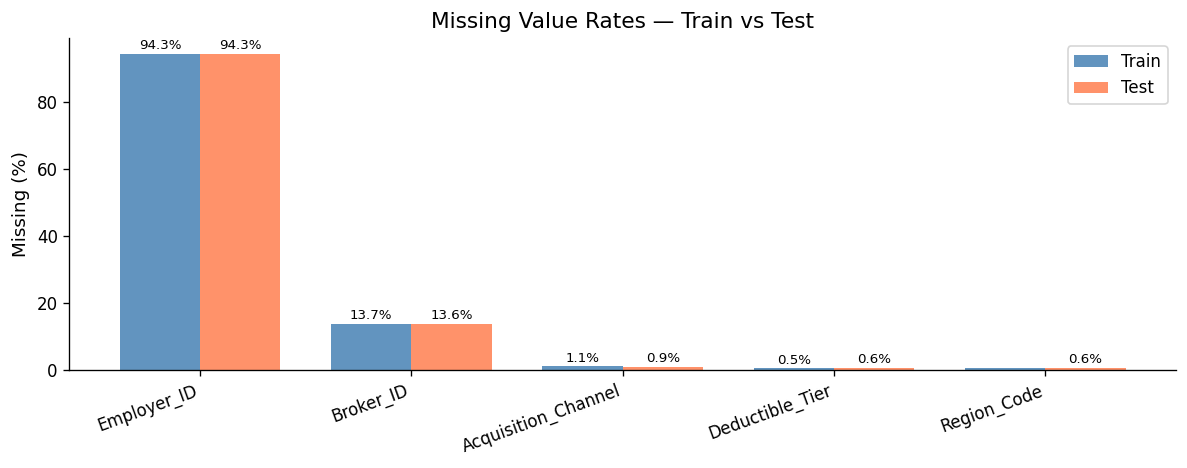

In [ ]:
cols_with_missing = ['Employer_ID', 'Broker_ID', 'Acquisition_Channel', 'Deductible_Tier', 'Region_Code']

train_pct = [train[c].isna().mean() * 100 for c in cols_with_missing]
test_pct  = [test[c].isna().mean()  * 100 for c in cols_with_missing]

x = np.arange(len(cols_with_missing))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
bars1 = ax.bar(x - width/2, train_pct, width, label='Train', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, test_pct,  width, label='Test',  color='coral',     alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cols_with_missing, rotation=20, ha='right')
ax.set_ylabel('Missing (%)')
ax.set_title('Missing Value Rates — Train vs Test')
ax.legend()
plt.tight_layout()
plt.savefig('assets/missing_train_test.png', bbox_inches='tight')
plt.show()

### 14.2 Categorical Feature Distributions — Test vs Train

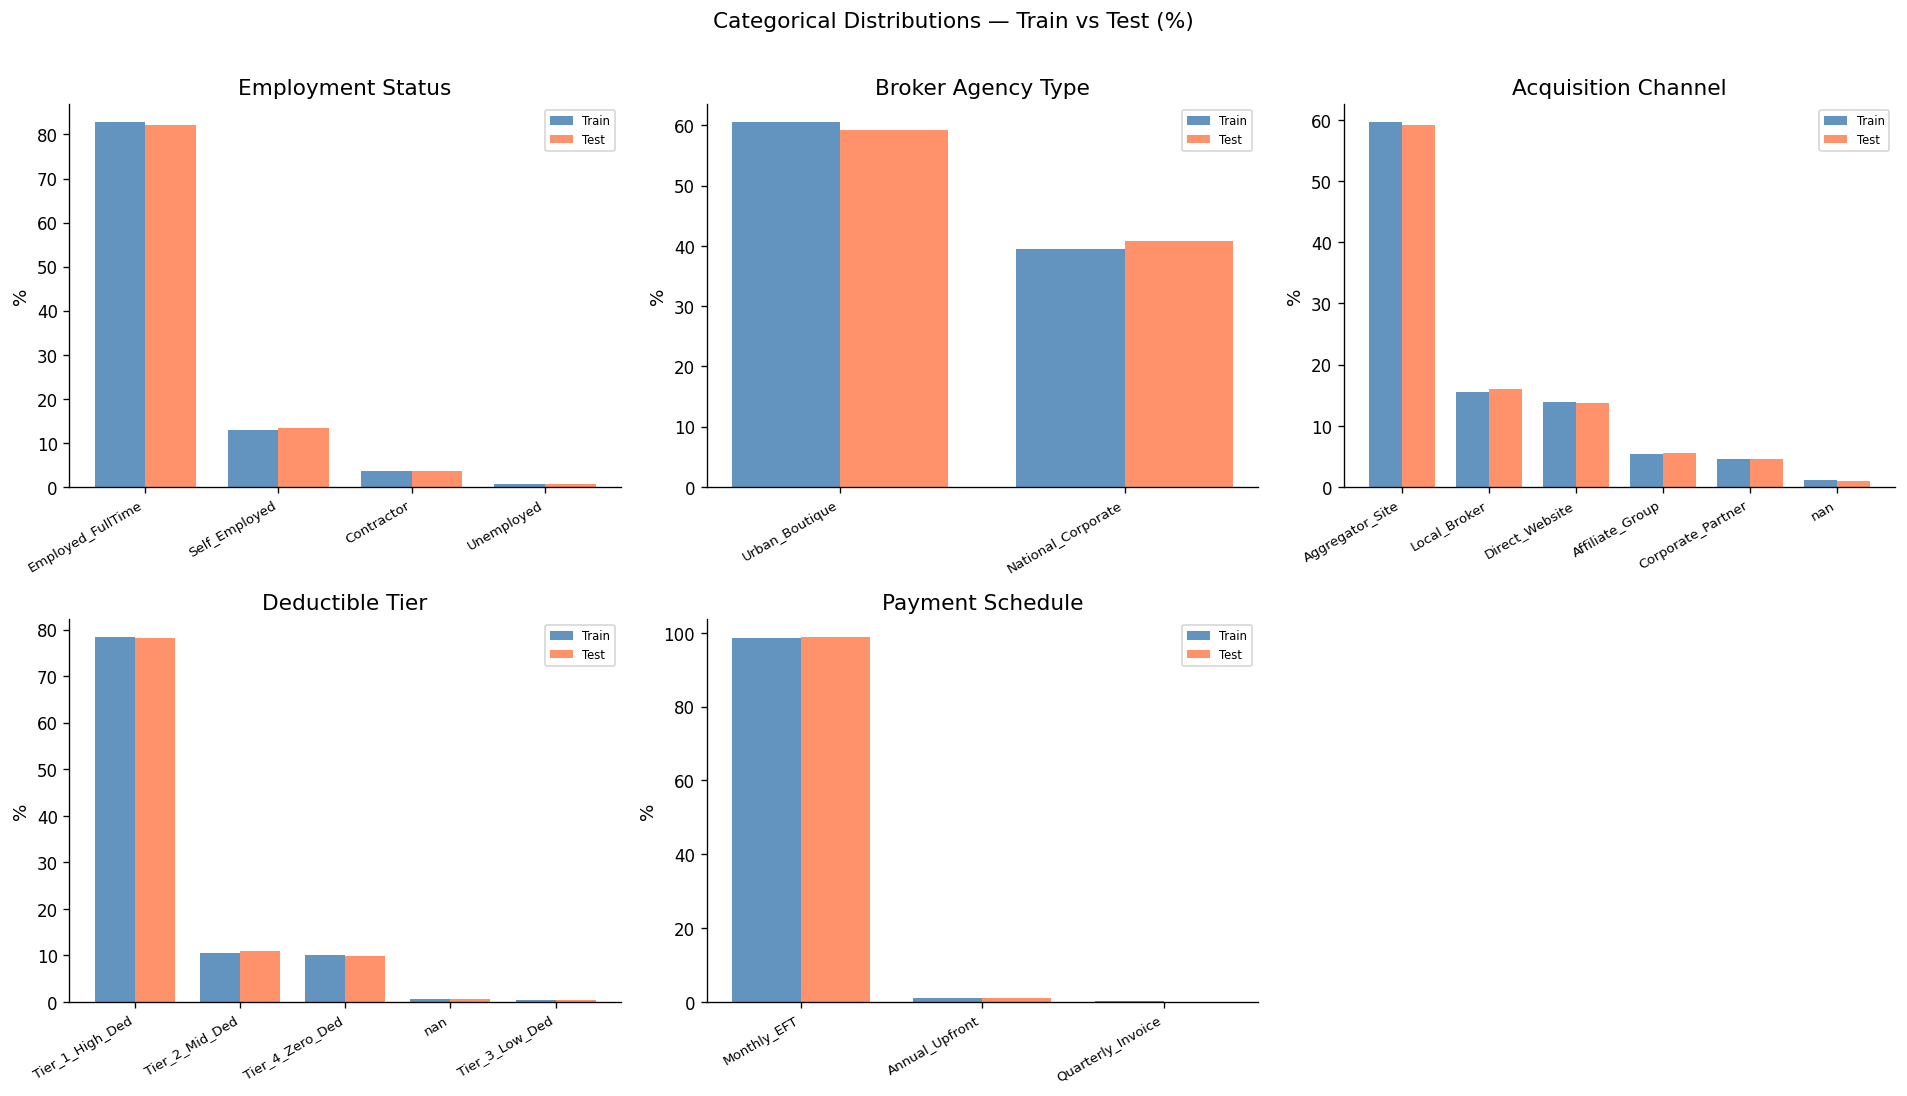

In [ ]:
cat_cols_show = [
    'Employment_Status', 'Broker_Agency_Type',
    'Acquisition_Channel', 'Deductible_Tier', 'Payment_Schedule',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_show):
    test_counts  = test[col].value_counts(dropna=False)
    train_counts = train[col].value_counts(dropna=False)
    all_cats = test_counts.index.union(train_counts.index)
    test_pcts  = test_counts.reindex(all_cats, fill_value=0)  / len(test)  * 100
    train_pcts = train_counts.reindex(all_cats, fill_value=0) / len(train) * 100

    x = np.arange(len(all_cats))
    w = 0.38
    ax.bar(x - w/2, train_pcts.values, w, label='Train', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, test_pcts.values,  w, label='Test',  color='coral',     alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(all_cats.astype(str), rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('%')
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Categorical Distributions — Train vs Test (%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('assets/test_categoricals.png', bbox_inches='tight')
plt.show()

### 14.3 Top Regions — Test vs Train

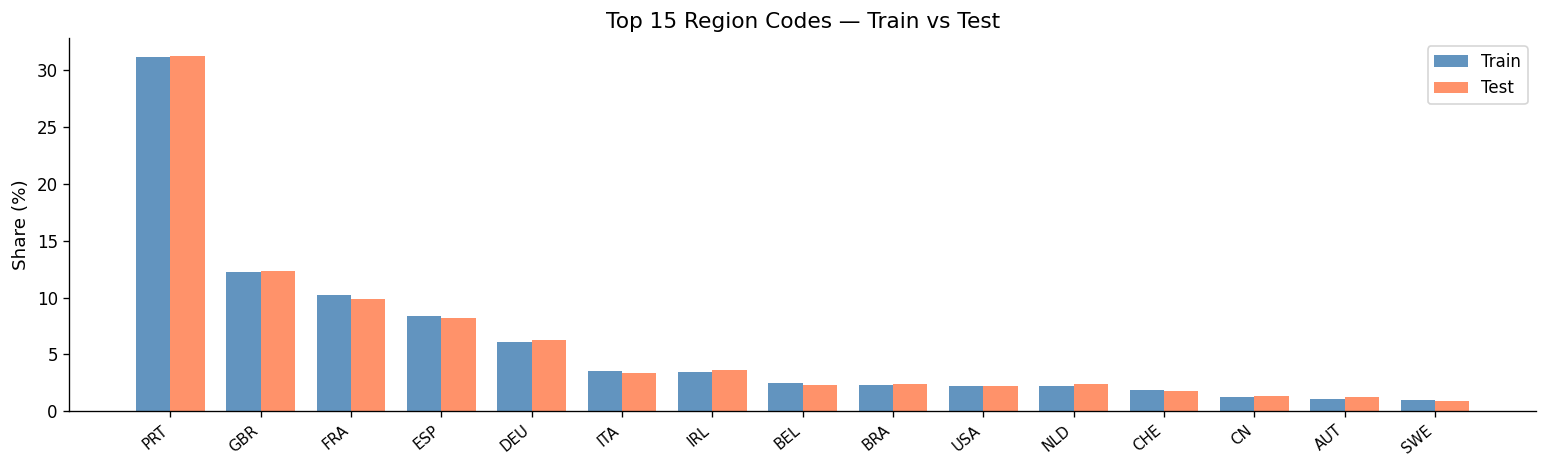

In [ ]:
top_n = 15
top_regions = train['Region_Code'].value_counts().head(top_n).index

train_reg = train['Region_Code'].value_counts(normalize=True).reindex(top_regions) * 100
test_reg  = test['Region_Code'].value_counts(normalize=True).reindex(top_regions, fill_value=0) * 100

x = np.arange(top_n)
w = 0.38

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, train_reg.values, w, label='Train', color='steelblue', alpha=0.85)
ax.bar(x + w/2, test_reg.values,  w, label='Test',  color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_regions, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Share (%)')
ax.set_title(f'Top {top_n} Region Codes — Train vs Test')
ax.legend()
plt.tight_layout()
plt.savefig('assets/test_regions.png', bbox_inches='tight')
plt.show()

### 14.4 Numerical Feature Distributions — Test vs Train

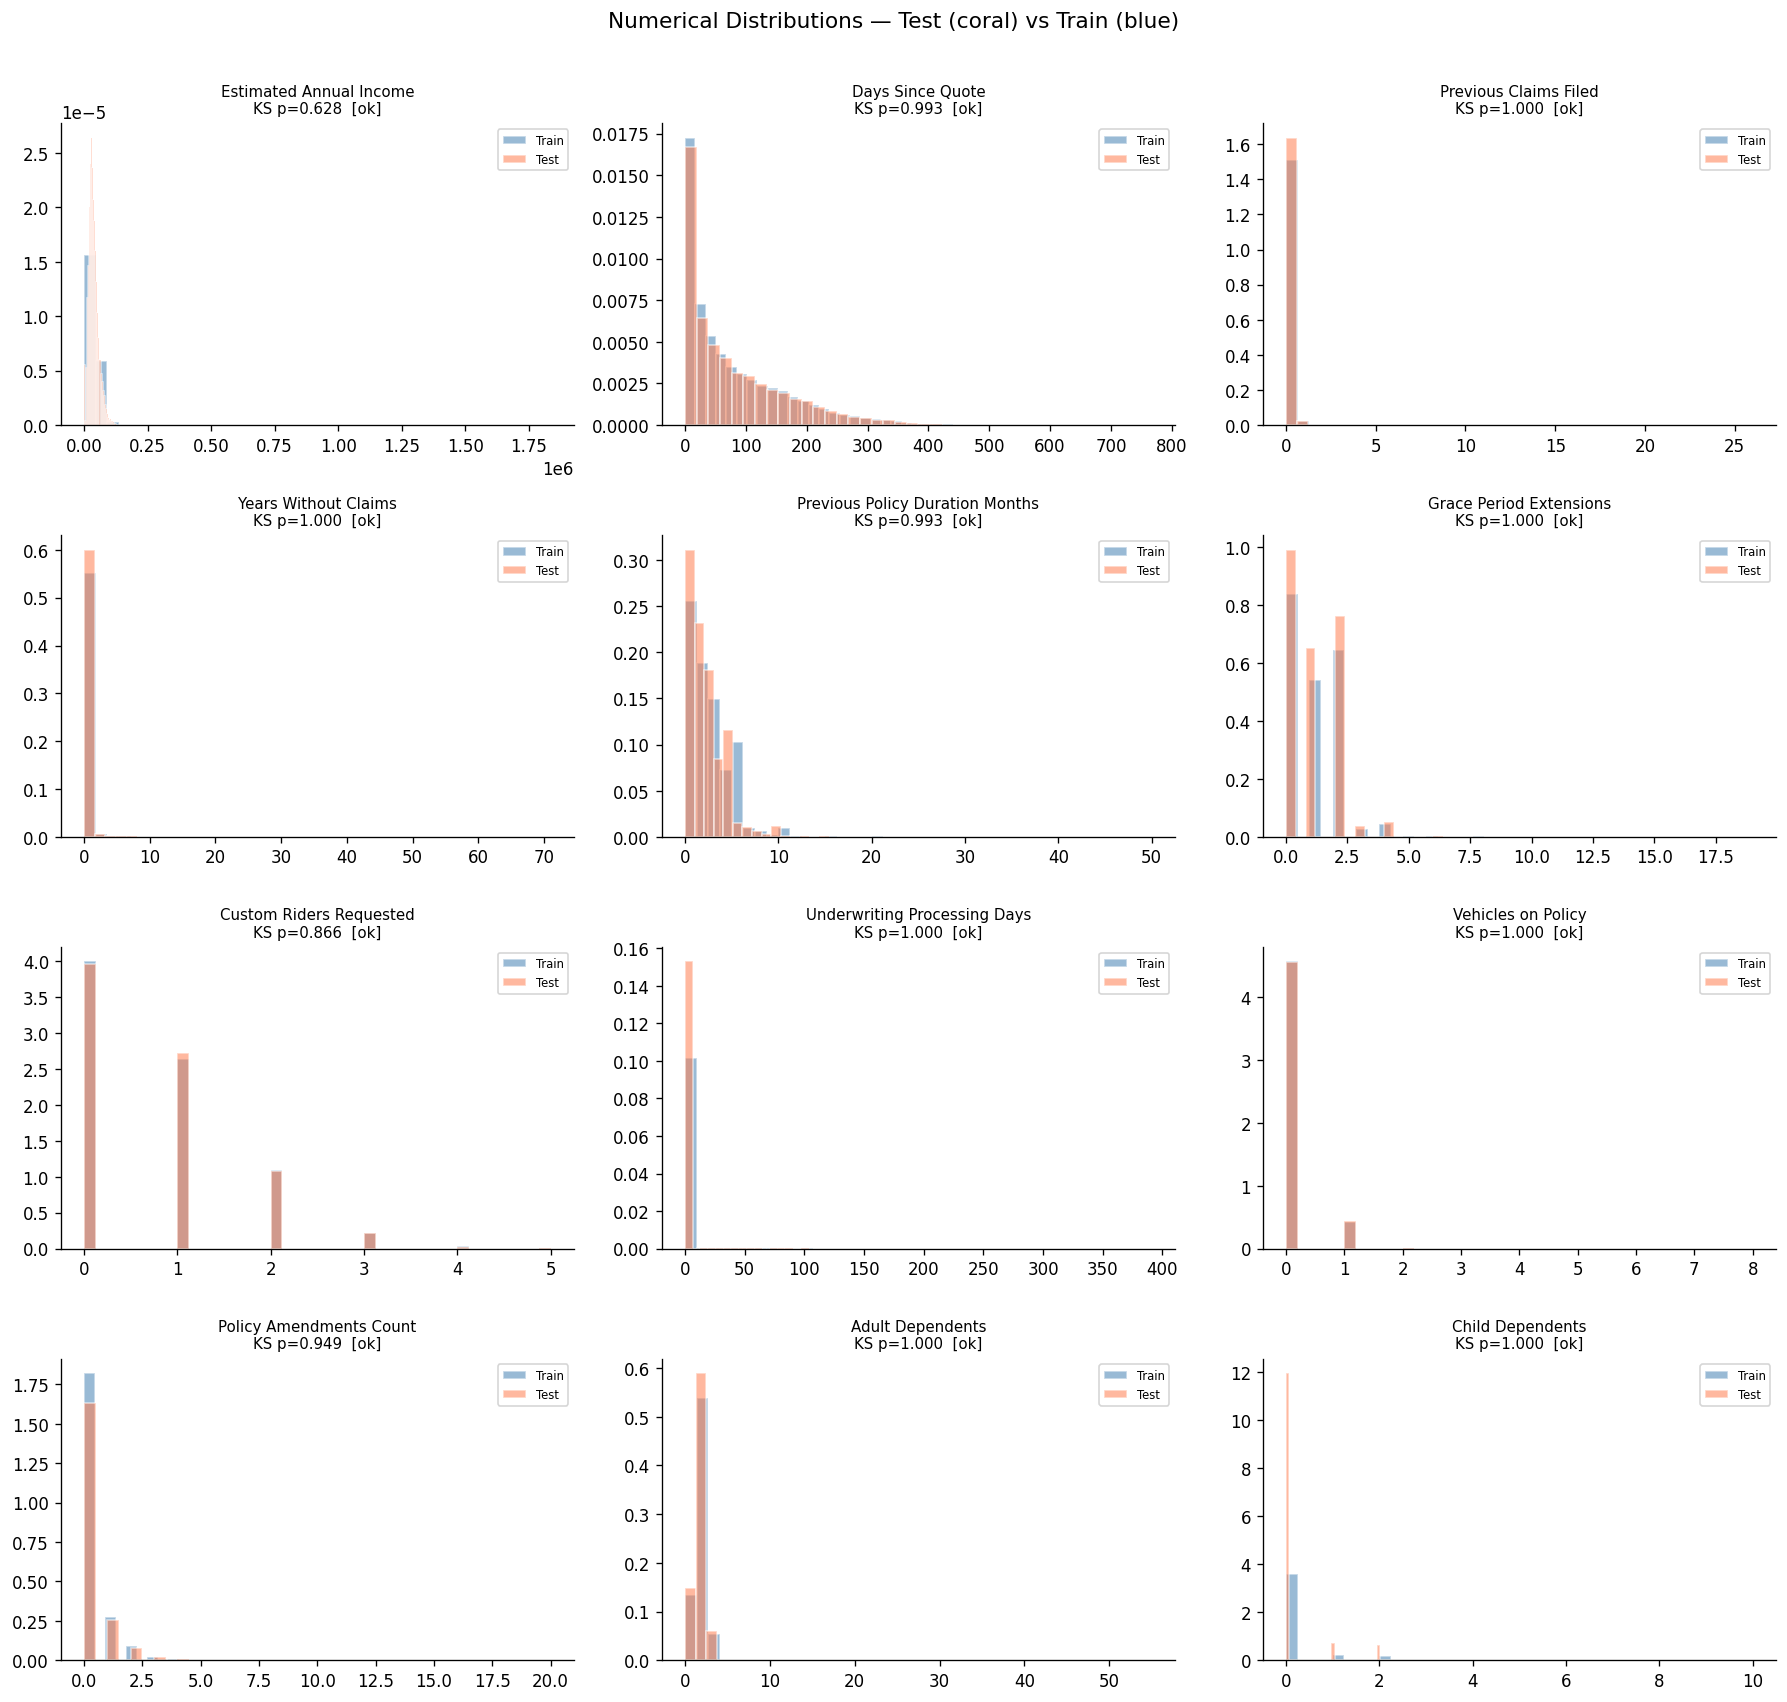

In [ ]:
num_cols_test = [
    'Estimated_Annual_Income', 'Days_Since_Quote',
    'Previous_Claims_Filed', 'Years_Without_Claims',
    'Previous_Policy_Duration_Months', 'Grace_Period_Extensions',
    'Custom_Riders_Requested', 'Underwriting_Processing_Days',
    'Vehicles_on_Policy', 'Policy_Amendments_Count',
    'Adult_Dependents', 'Child_Dependents',
]

nrows = (len(num_cols_test) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, num_cols_test):
    ax.hist(train[col].dropna(), bins=40, alpha=0.55, density=True,
            color='steelblue', label='Train', edgecolor='white')
    ax.hist(test[col].dropna(),  bins=40, alpha=0.55, density=True,
            color='coral',     label='Test',  edgecolor='white')
    ks_stat, ks_p = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    flag = '  [!] shift' if ks_p < 0.05 else '  [ok]'
    ax.set_title(f'{col.replace("_", " ")}\nKS p={ks_p:.3f}{flag}', fontsize=9)
    ax.legend(fontsize=7)

for ax in axes[len(num_cols_test):]:
    ax.set_visible(False)

plt.suptitle('Numerical Distributions — Test (coral) vs Train (blue)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('assets/test_numericals.png', bbox_inches='tight')
plt.show()

### 14.5 Temporal Distributions — Test vs Train

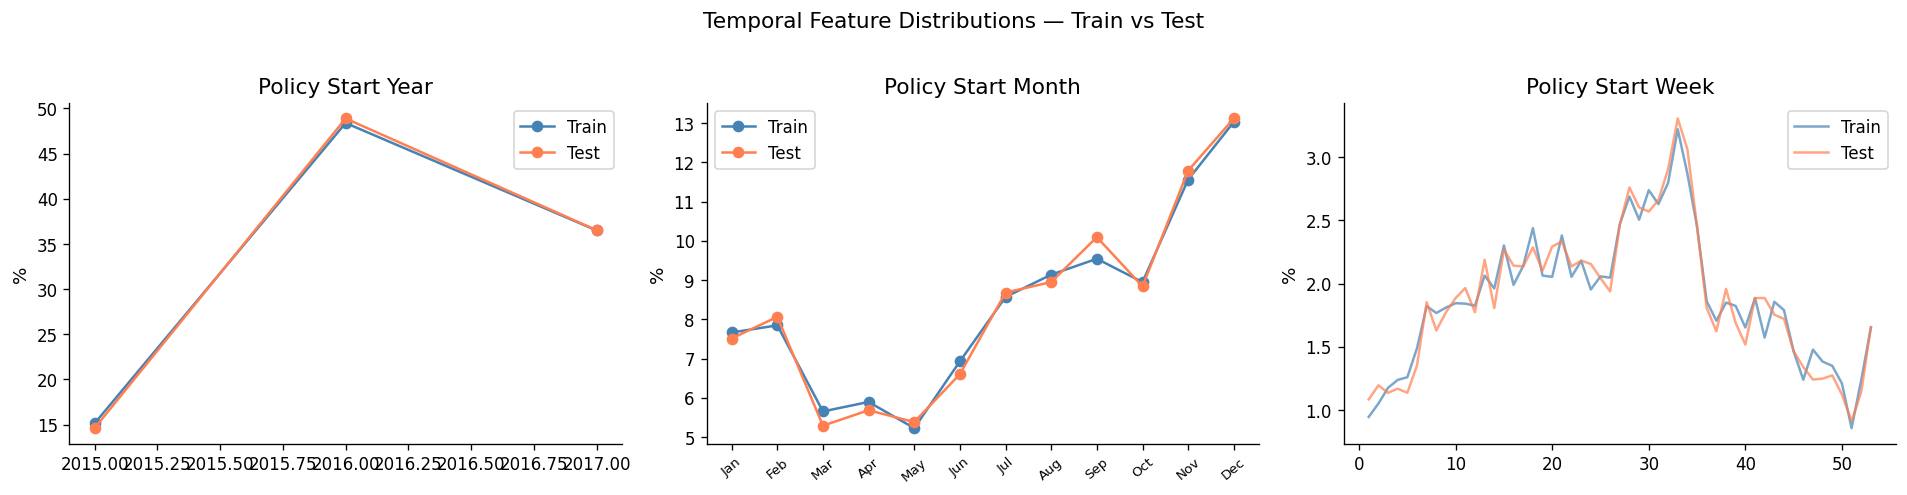

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Year
for df, label, color in [(train, 'Train', 'steelblue'), (test, 'Test', 'coral')]:
    pcts = df['Policy_Start_Year'].value_counts().sort_index() / len(df) * 100
    axes[0].plot(pcts.index, pcts.values, marker='o', label=label, color=color)
axes[0].set_title('Policy Start Year'); axes[0].set_ylabel('%'); axes[0].legend()

# Month (string -> int)
MONTH_ORDER_LOCAL = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}
for df, label, color in [(train, 'Train', 'steelblue'), (test, 'Test', 'coral')]:
    month_num = df['Policy_Start_Month'].map(MONTH_ORDER_LOCAL)
    pcts = month_num.value_counts().sort_index() / len(df) * 100
    axes[1].plot(pcts.index, pcts.values, marker='o', label=label, color=color)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=40, fontsize=8)
axes[1].set_title('Policy Start Month'); axes[1].set_ylabel('%'); axes[1].legend()

# Week
for df, label, color in [(train, 'Train', 'steelblue'), (test, 'Test', 'coral')]:
    pcts = df['Policy_Start_Week'].value_counts().sort_index() / len(df) * 100
    axes[2].plot(pcts.index, pcts.values, alpha=0.7, label=label, color=color)
axes[2].set_title('Policy Start Week'); axes[2].set_ylabel('%'); axes[2].legend()

plt.suptitle('Temporal Feature Distributions — Train vs Test', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('assets/test_temporal.png', bbox_inches='tight')
plt.show()

### 14.6 Top Brokers — Test vs Train

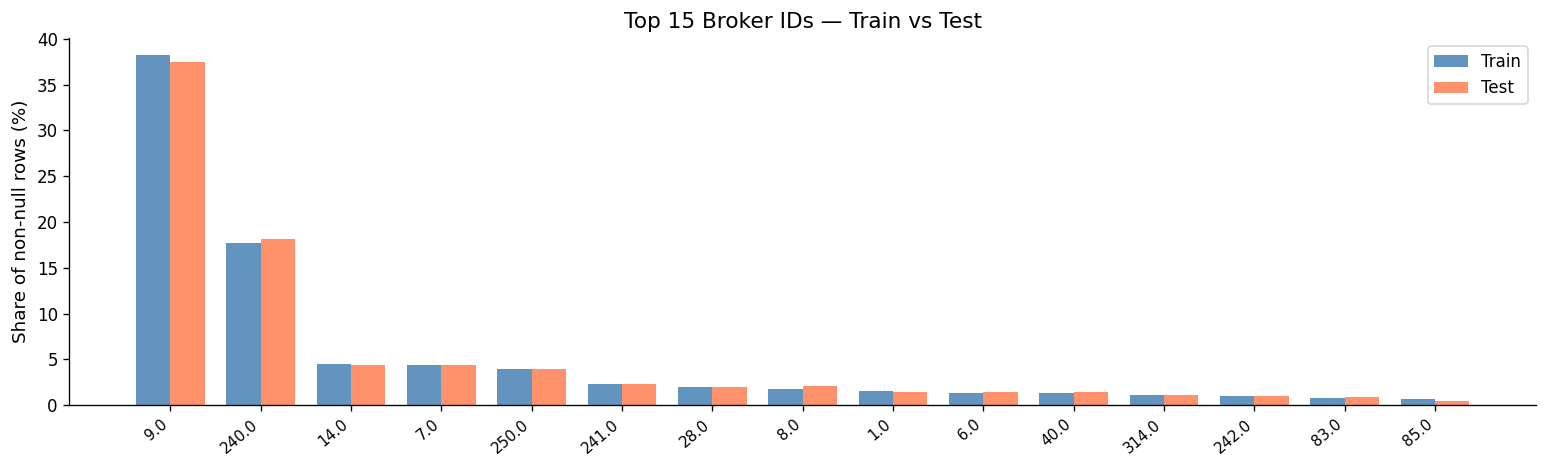


Broker volume in test (top 10):
Broker_ID
9.0      4922
240.0    2382
7.0       582
14.0      577
250.0     523
241.0     303
8.0       269
28.0      257
40.0      187
1.0       187


In [ ]:
top_n = 15
top_brokers = train['Broker_ID'].value_counts().head(top_n).index

train_br = train['Broker_ID'].value_counts(normalize=True).reindex(top_brokers) * 100
test_br  = test['Broker_ID'].value_counts(normalize=True).reindex(top_brokers, fill_value=0) * 100

x = np.arange(top_n)
w = 0.38

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, train_br.values, w, label='Train', color='steelblue', alpha=0.85)
ax.bar(x + w/2, test_br.values,  w, label='Test',  color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in top_brokers], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Share of non-null rows (%)')
ax.set_title(f'Top {top_n} Broker IDs — Train vs Test')
ax.legend()
plt.tight_layout()
plt.savefig('assets/test_brokers.png', bbox_inches='tight')
plt.show()

print('\nBroker volume in test (top 10):')
print(test['Broker_ID'].value_counts().head(10).to_string())

### 14.7 KS Test Summary — All Numerical Features

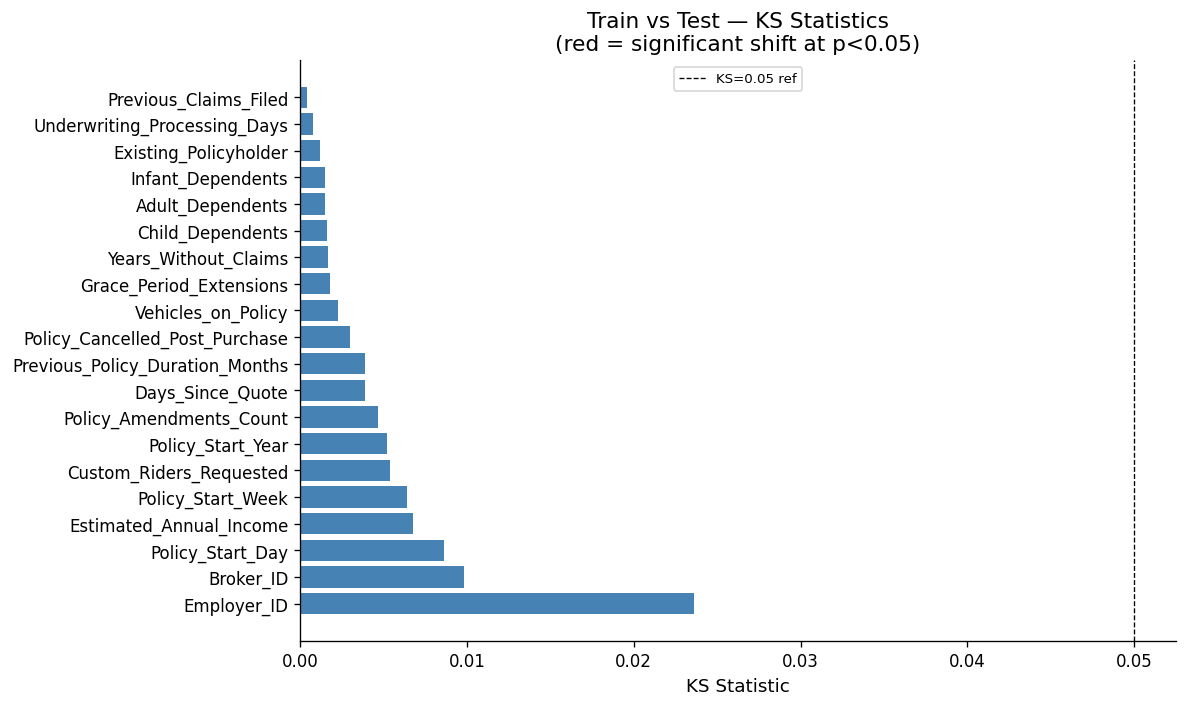

,Feature,KS Statistic,p-value,Shift?
0,Employer_ID,0.0236,0.8281,no
1,Broker_ID,0.0098,0.2654,no
2,Policy_Start_Day,0.0086,0.3286,no
3,Estimated_Annual_Income,0.0068,0.6283,no
4,Policy_Start_Week,0.0064,0.7014,no
5,Custom_Riders_Requested,0.0054,0.8655,no
6,Policy_Start_Year,0.0052,0.8908,no
7,Policy_Amendments_Count,0.0047,0.9494,no
8,Days_Since_Quote,0.0039,0.9927,no
9,Previous_Policy_Duration_Months,0.0039,0.9927,no


In [ ]:
all_num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
                if c != TARGET and c in test.columns]

ks_rows = []
for col in all_num_cols:
    stat, p = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    ks_rows.append({'Feature': col,
                    'KS Statistic': round(stat, 4),
                    'p-value': round(p, 4),
                    'Shift?': 'YES' if p < 0.05 else 'no'})

ks_df = pd.DataFrame(ks_rows).sort_values('KS Statistic', ascending=False)

colors = ['tomato' if r == 'YES' else 'steelblue' for r in ks_df['Shift?']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ks_df['Feature'], ks_df['KS Statistic'], color=colors)
ax.axvline(0.05, color='black', linestyle='--', linewidth=0.8, label='KS=0.05 ref')
ax.set_xlabel('KS Statistic')
ax.set_title('Train vs Test — KS Statistics\n(red = significant shift at p<0.05)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('assets/test_ks_summary.png', bbox_inches='tight')
plt.show()

display(ks_df.reset_index(drop=True))

## 15. Column Dictionary — Decision Visualizations

One figure per column group. Each chart answers a specific modelling question:
**drop or keep? how to encode? outliers? feature engineering needed?**

### 15.1 Demographics

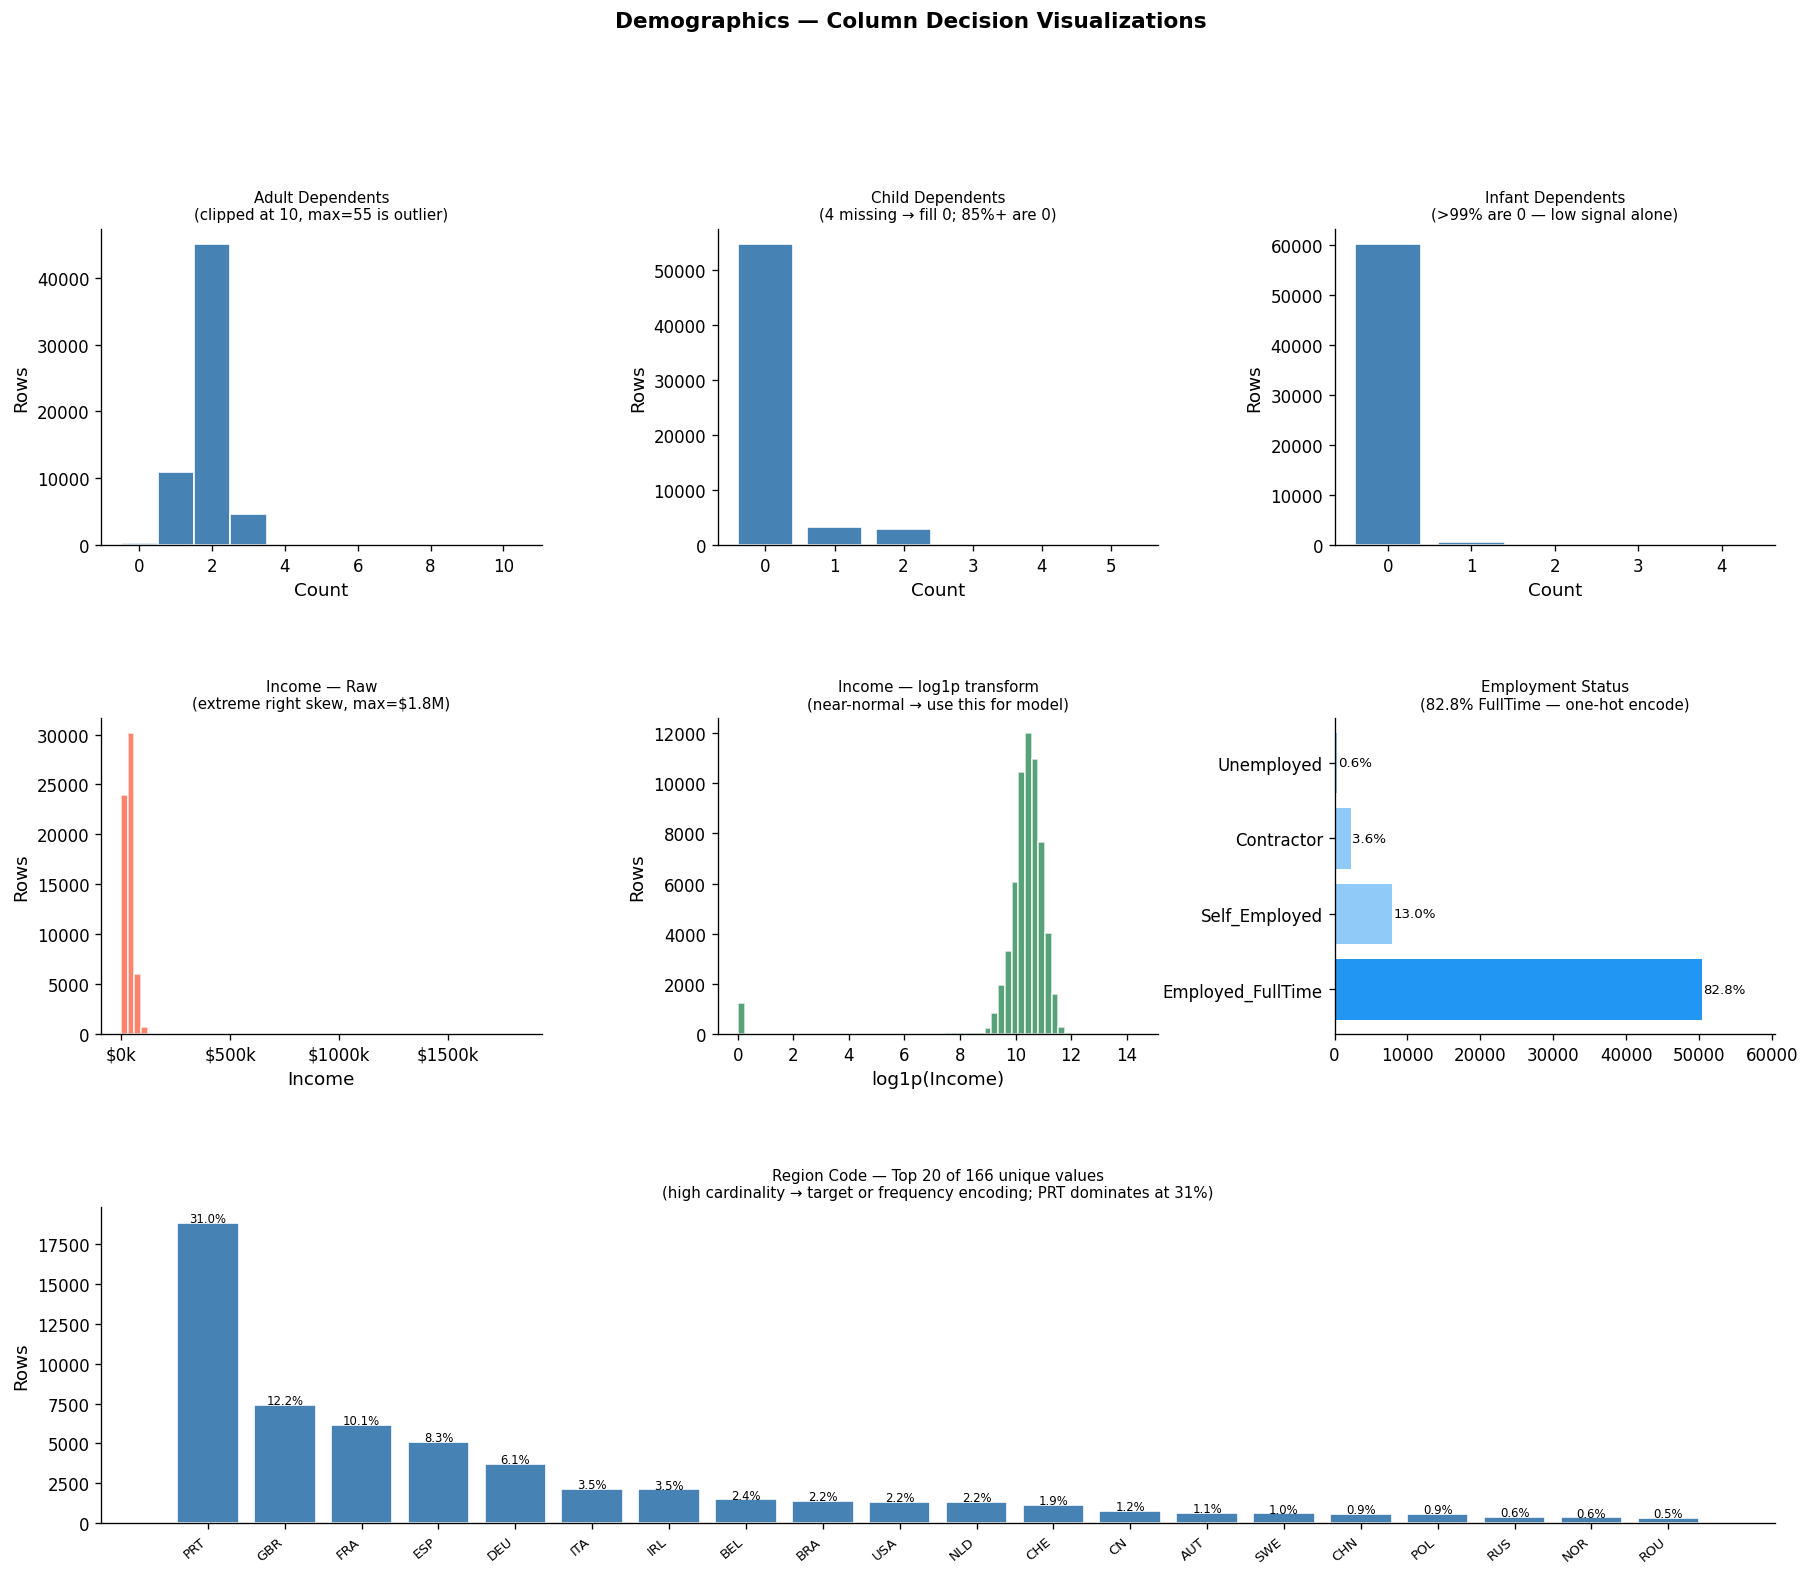

In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4)

# ── Adult Dependents: histogram (note the outlier at 55) ──
ax = fig.add_subplot(gs[0, 0])
clipped = train['Adult_Dependents'].clip(upper=10)
ax.hist(clipped, bins=range(0, 12), color='steelblue', edgecolor='white', align='left')
ax.set_title('Adult Dependents\n(clipped at 10, max=55 is outlier)', fontsize=9)
ax.set_xlabel('Count'); ax.set_ylabel('Rows')

# ── Child Dependents: value counts bar ──
ax = fig.add_subplot(gs[0, 1])
vc = train['Child_Dependents'].fillna(0).clip(upper=5).astype(int).value_counts().sort_index()
ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white')
ax.set_title('Child Dependents\n(4 missing → fill 0; 85%+ are 0)', fontsize=9)
ax.set_xlabel('Count'); ax.set_ylabel('Rows')

# ── Infant Dependents ──
ax = fig.add_subplot(gs[0, 2])
vc = train['Infant_Dependents'].clip(upper=4).value_counts().sort_index()
ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white')
ax.set_title('Infant Dependents\n(>99% are 0 — low signal alone)', fontsize=9)
ax.set_xlabel('Count'); ax.set_ylabel('Rows')

# ── Income: raw vs log1p side by side ──
ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(train['Estimated_Annual_Income'], bins=60, color='tomato', edgecolor='white', alpha=0.8)
ax1.set_title('Income — Raw\n(extreme right skew, max=$1.8M)', fontsize=9)
ax1.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax1.set_xlabel('Income'); ax1.set_ylabel('Rows')

ax2 = fig.add_subplot(gs[1, 1])
import numpy as np
ax2.hist(np.log1p(train['Estimated_Annual_Income']), bins=60, color='seagreen', edgecolor='white', alpha=0.8)
ax2.set_title('Income — log1p transform\n(near-normal → use this for model)', fontsize=9)
ax2.set_xlabel('log1p(Income)'); ax2.set_ylabel('Rows')

# ── Employment Status ──
ax = fig.add_subplot(gs[1, 2])
vc = train['Employment_Status'].value_counts()
colors = ['#2196F3' if i==0 else '#90CAF9' for i in range(len(vc))]
ax.barh(vc.index, vc.values, color=colors)
for i,(v,n) in enumerate(zip(vc.values, vc.index)):
    ax.text(v+200, i, f'{v/len(train)*100:.1f}%', va='center', fontsize=8)
ax.set_title('Employment Status\n(82.8% FullTime — one-hot encode)', fontsize=9)
ax.set_xlim(0, vc.max()*1.2)

# ── Region Code: top 20 ──
ax = fig.add_subplot(gs[2, :])
top20 = train['Region_Code'].value_counts().head(20)
ax.bar(range(len(top20)), top20.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=40, ha='right', fontsize=8)
for i, v in enumerate(top20.values):
    ax.text(i, v+50, f'{v/len(train)*100:.1f}%', ha='center', fontsize=7)
ax.set_title(f'Region Code — Top 20 of 166 unique values\n(high cardinality → target or frequency encoding; PRT dominates at 31%)', fontsize=9)
ax.set_ylabel('Rows')

plt.suptitle('Demographics — Column Decision Visualizations', fontsize=13, y=1.01, fontweight='bold')
plt.savefig('assets/col_demographics.png', bbox_inches='tight')
plt.show()

### 15.2 Risk History

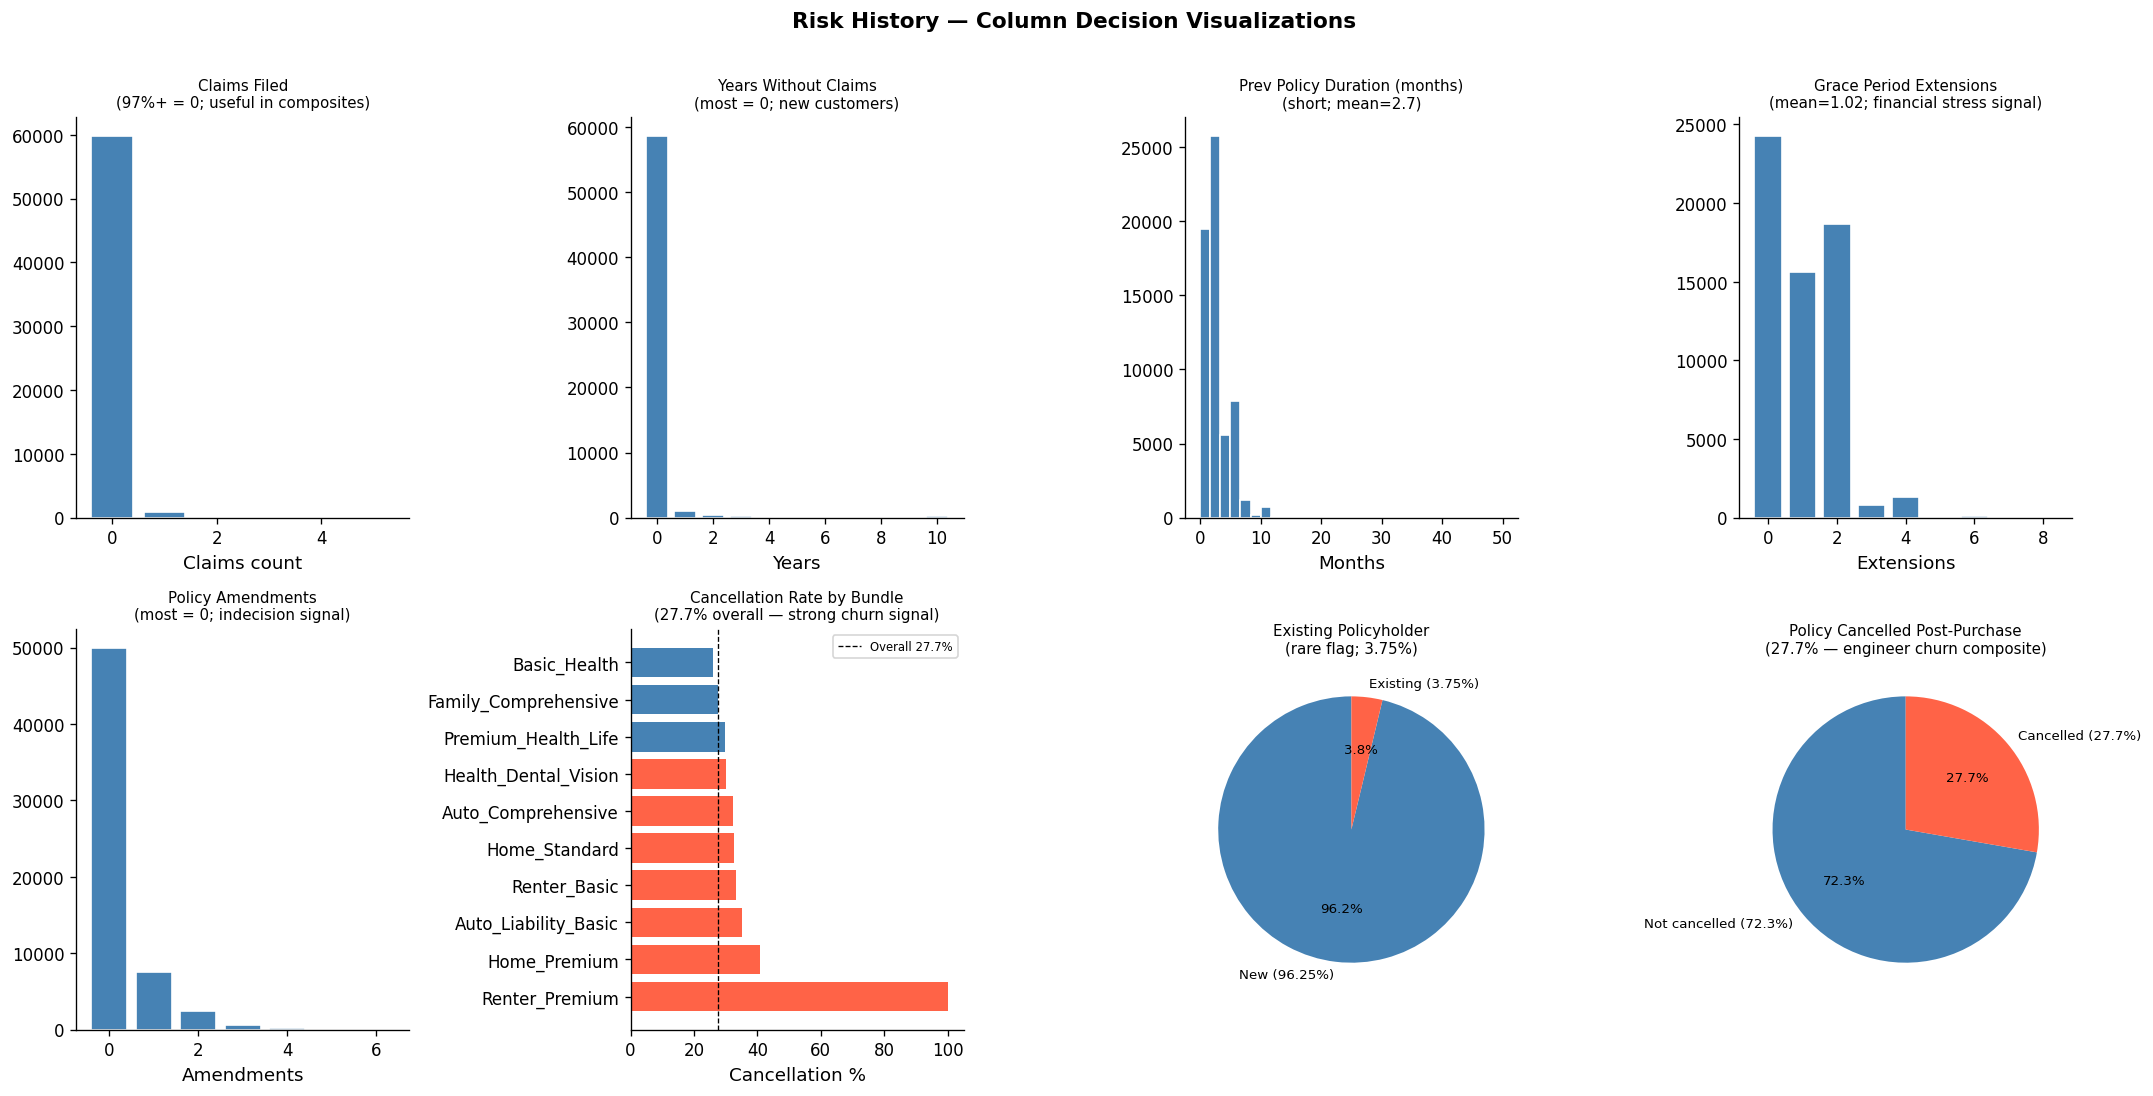

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Claims filed (zoom 0-5)
vc = train['Previous_Claims_Filed'].clip(upper=5).value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Claims Filed\n(97%+ = 0; useful in composites)', fontsize=9)
axes[0].set_xlabel('Claims count')

# Years without claims (zoom 0-10)
vc = train['Years_Without_Claims'].clip(upper=10).value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[1].set_title('Years Without Claims\n(most = 0; new customers)', fontsize=9)
axes[1].set_xlabel('Years')

# Policy duration
axes[2].hist(train['Previous_Policy_Duration_Months'], bins=30, color='steelblue', edgecolor='white')
axes[2].set_title('Prev Policy Duration (months)\n(short; mean=2.7)', fontsize=9)
axes[2].set_xlabel('Months')

# Grace period extensions
vc = train['Grace_Period_Extensions'].clip(upper=8).value_counts().sort_index()
axes[3].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[3].set_title('Grace Period Extensions\n(mean=1.02; financial stress signal)', fontsize=9)
axes[3].set_xlabel('Extensions')

# Policy amendments
vc = train['Policy_Amendments_Count'].clip(upper=6).value_counts().sort_index()
axes[4].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[4].set_title('Policy Amendments\n(most = 0; indecision signal)', fontsize=9)
axes[4].set_xlabel('Amendments')

# Cancellation rate: stacked bar by bundle
cancelled = train.groupby('Bundle_Name')['Policy_Cancelled_Post_Purchase'].mean().sort_values(ascending=False)
colors_bar = ['tomato' if v > 0.30 else 'steelblue' for v in cancelled.values]
axes[5].barh(cancelled.index, cancelled.values * 100, color=colors_bar)
axes[5].axvline(27.7, color='black', linestyle='--', linewidth=0.8, label='Overall 27.7%')
axes[5].set_title('Cancellation Rate by Bundle\n(27.7% overall — strong churn signal)', fontsize=9)
axes[5].set_xlabel('Cancellation %')
axes[5].legend(fontsize=7)

# Existing policyholder
vals = train['Existing_Policyholder'].value_counts()
axes[6].pie(vals.values, labels=['New (96.25%)', 'Existing (3.75%)'],
            colors=['steelblue','tomato'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
axes[6].set_title('Existing Policyholder\n(rare flag; 3.75%)', fontsize=9)

# Policy cancelled overall
vals = train['Policy_Cancelled_Post_Purchase'].value_counts()
axes[7].pie(vals.values, labels=['Not cancelled (72.3%)', 'Cancelled (27.7%)'],
            colors=['steelblue','tomato'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
axes[7].set_title('Policy Cancelled Post-Purchase\n(27.7% — engineer churn composite)', fontsize=9)

plt.suptitle('Risk History — Column Decision Visualizations', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/col_risk_history.png', bbox_inches='tight')
plt.show()

### 15.3 Policy Preferences

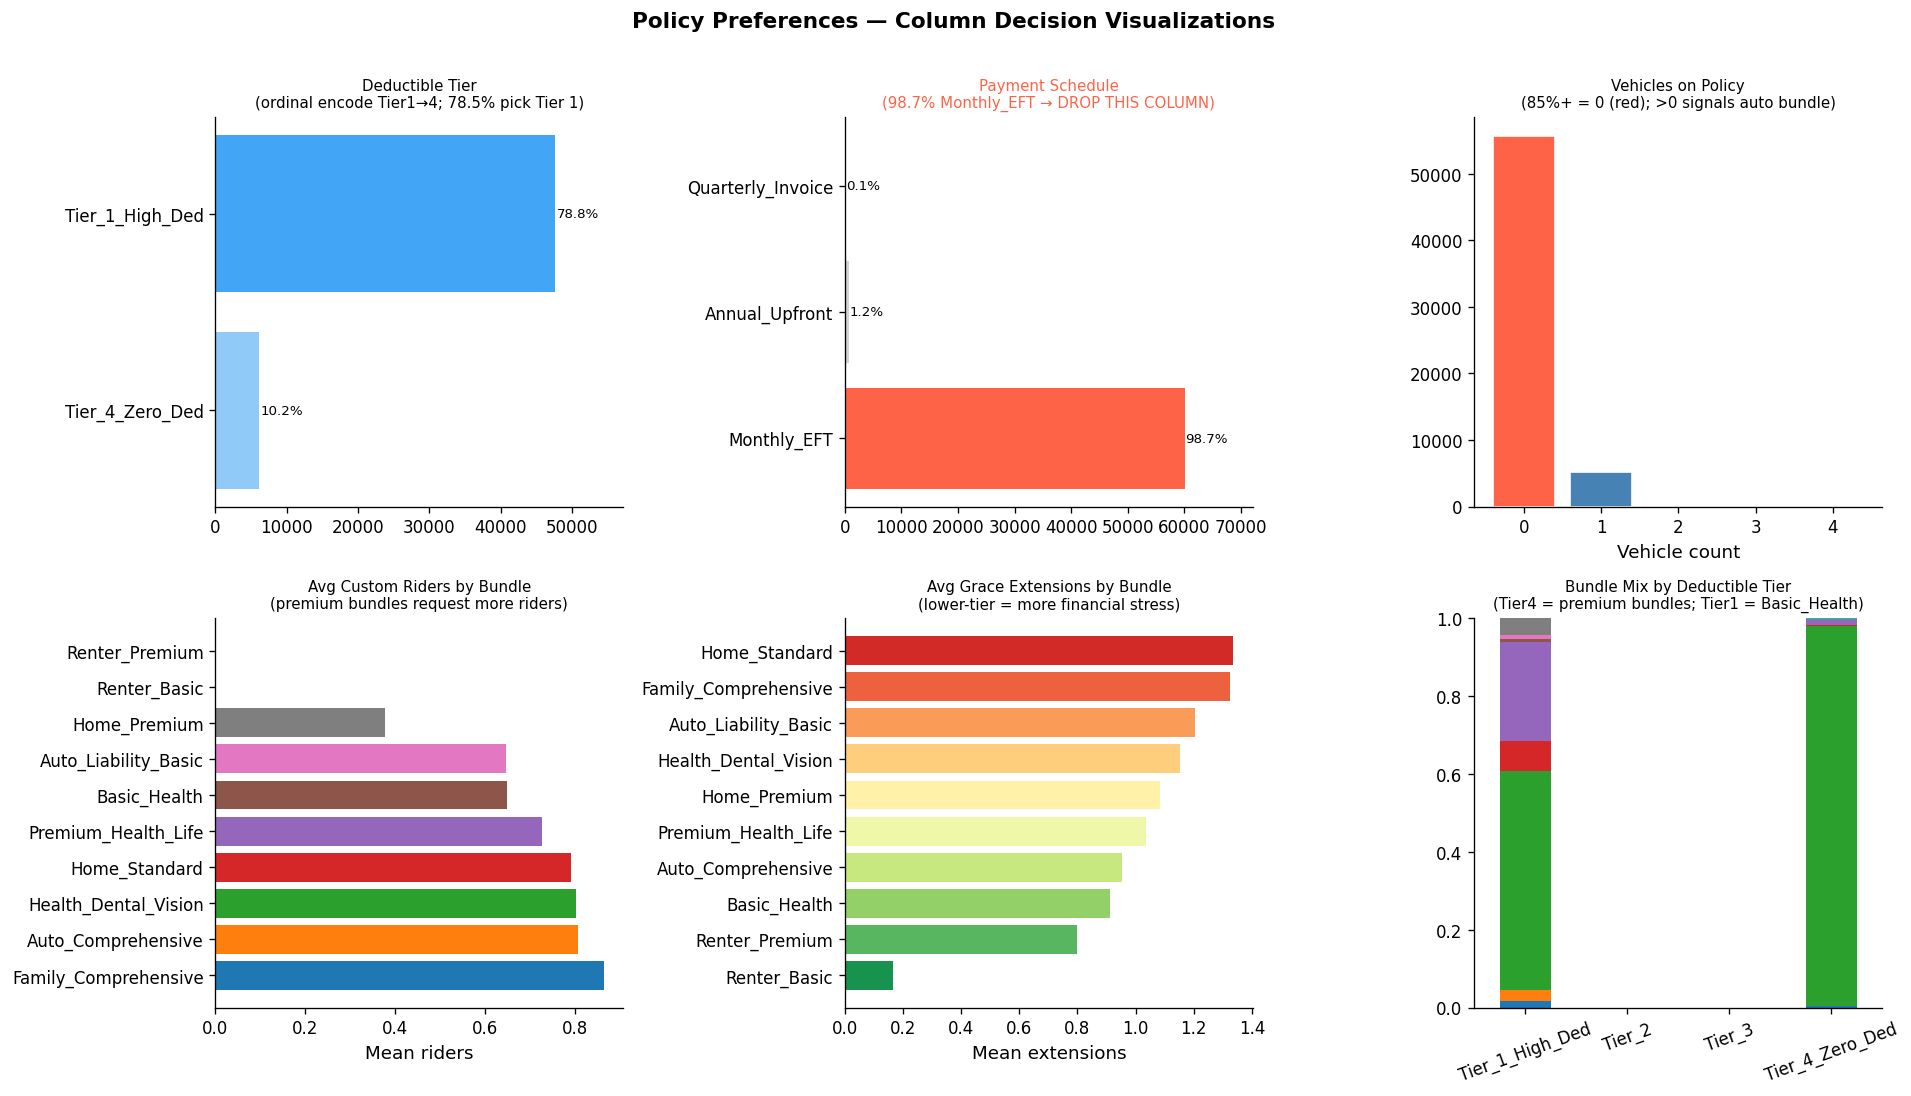

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Deductible Tier
vc = train['Deductible_Tier'].value_counts()
tier_order = ['Tier_1_High_Ded', 'Tier_2', 'Tier_3', 'Tier_4_Zero_Ded']
vc = vc.reindex([t for t in tier_order if t in vc.index])
colors_tier = ['#1565C0','#1976D2','#42A5F5','#90CAF9']
axes[0].barh(vc.index[::-1], vc.values[::-1], color=colors_tier[::-1])
for i, (v, n) in enumerate(zip(vc.values[::-1], vc.index[::-1])):
    axes[0].text(v+200, i, f'{v/train["Deductible_Tier"].notna().sum()*100:.1f}%', va='center', fontsize=8)
axes[0].set_title('Deductible Tier\n(ordinal encode Tier1→4; 78.5% pick Tier 1)', fontsize=9)
axes[0].set_xlim(0, vc.max()*1.2)

# Payment Schedule — near zero variance
vc = train['Payment_Schedule'].value_counts()
colors_pay = ['tomato' if i == 0 else 'lightgrey' for i in range(len(vc))]
axes[1].barh(vc.index, vc.values, color=colors_pay)
for i, v in enumerate(vc.values):
    axes[1].text(v+100, i, f'{v/len(train)*100:.1f}%', va='center', fontsize=8)
axes[1].set_title('Payment Schedule\n(98.7% Monthly_EFT → DROP THIS COLUMN)', fontsize=9, color='tomato')
axes[1].set_xlim(0, vc.max()*1.2)

# Vehicles on policy
vc = train['Vehicles_on_Policy'].clip(upper=4).value_counts().sort_index()
colors_veh = ['tomato' if i == 0 else 'steelblue' for i in vc.index]
axes[2].bar(vc.index, vc.values, color=colors_veh, edgecolor='white')
axes[2].set_title('Vehicles on Policy\n(85%+ = 0 (red); >0 signals auto bundle)', fontsize=9)
axes[2].set_xlabel('Vehicle count')

# Custom riders by bundle
riders_mean = train.groupby('Bundle_Name')['Custom_Riders_Requested'].mean().sort_values(ascending=False)
axes[3].barh(riders_mean.index, riders_mean.values, color=sns.color_palette('tab10', 10))
axes[3].set_title('Avg Custom Riders by Bundle\n(premium bundles request more riders)', fontsize=9)
axes[3].set_xlabel('Mean riders')

# Grace period extensions by bundle
grace_mean = train.groupby('Bundle_Name')['Grace_Period_Extensions'].mean().sort_values(ascending=True)
axes[4].barh(grace_mean.index, grace_mean.values, color=sns.color_palette('RdYlGn_r', 10))
axes[4].set_title('Avg Grace Extensions by Bundle\n(lower-tier = more financial stress)', fontsize=9)
axes[4].set_xlabel('Mean extensions')

# Deductible tier vs target (stacked %)
ded_pivot = (
    train.dropna(subset=['Deductible_Tier'])
    .groupby(['Deductible_Tier', 'Bundle_Name']).size().unstack(fill_value=0)
    .reindex(tier_order).apply(lambda r: r/r.sum(), axis=1)
)
ded_pivot.plot(kind='bar', stacked=True, ax=axes[5], colormap='tab10', legend=False)
axes[5].set_title('Bundle Mix by Deductible Tier\n(Tier4 = premium bundles; Tier1 = Basic_Health)', fontsize=9)
axes[5].set_xlabel('')
axes[5].tick_params(axis='x', rotation=20)

plt.suptitle('Policy Preferences — Column Decision Visualizations', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/col_policy_prefs.png', bbox_inches='tight')
plt.show()

### 15.4 Sales & Underwriting

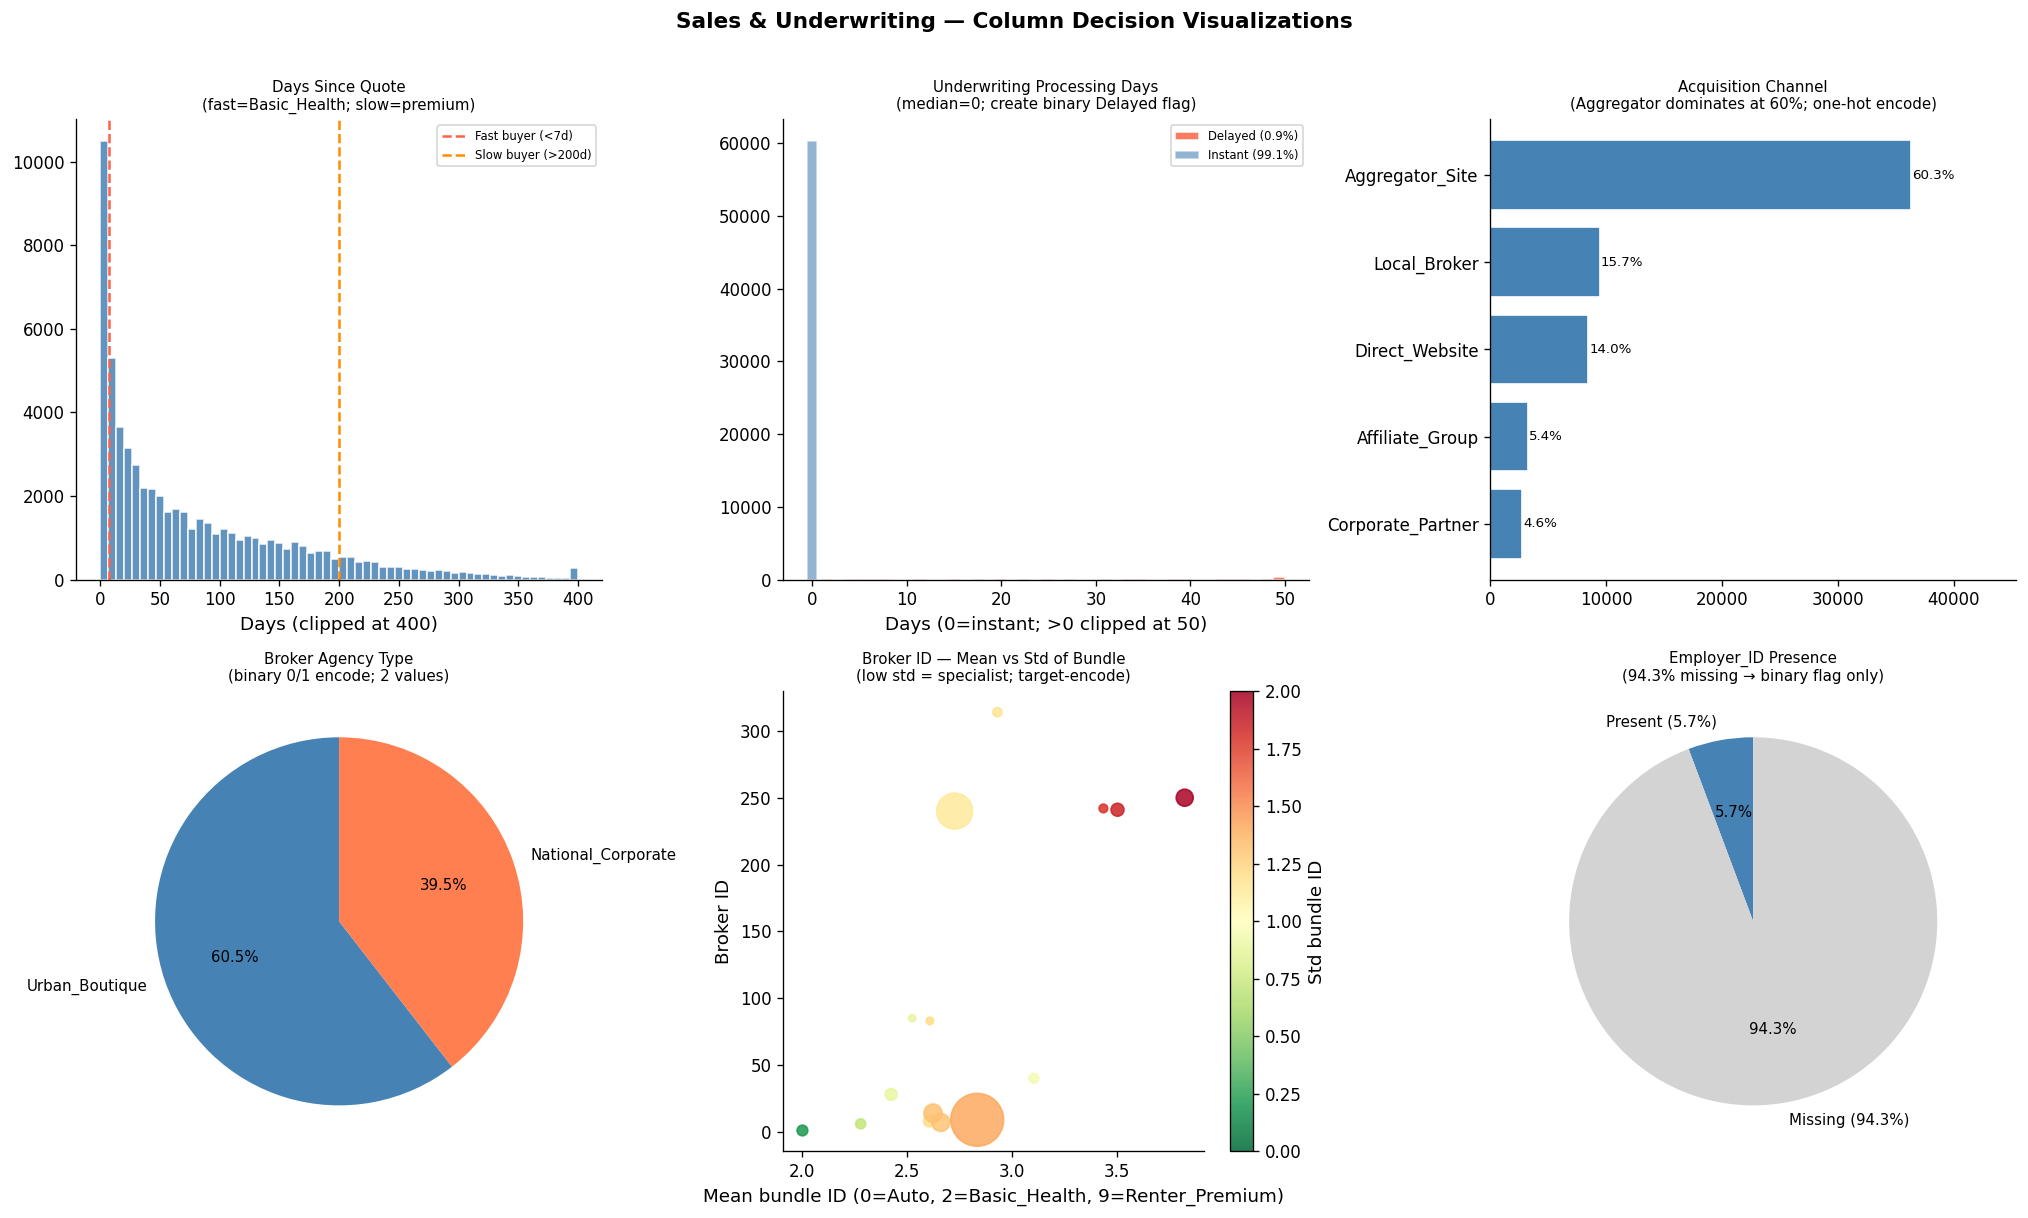

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Days Since Quote: histogram + threshold lines
axes[0, 0].hist(train['Days_Since_Quote'].clip(upper=400), bins=60,
                color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(7,   color='tomato',    linestyle='--', linewidth=1.5, label='Fast buyer (<7d)')
axes[0, 0].axvline(200, color='darkorange', linestyle='--', linewidth=1.5, label='Slow buyer (>200d)')
axes[0, 0].set_title('Days Since Quote\n(fast=Basic_Health; slow=premium)', fontsize=9)
axes[0, 0].set_xlabel('Days (clipped at 400)')
axes[0, 0].legend(fontsize=7)

# Underwriting days: log-scale histogram + flag
uw = train['Underwriting_Processing_Days']
delayed_pct = (uw > 0).mean() * 100
axes[0, 1].hist(uw[uw > 0].clip(upper=50), bins=40, color='tomato', edgecolor='white', alpha=0.85, label=f'Delayed ({delayed_pct:.1f}%)')
axes[0, 1].hist([0]*int((uw == 0).sum()), bins=1, color='steelblue', edgecolor='white', alpha=0.6, label=f'Instant ({100-delayed_pct:.1f}%)')
axes[0, 1].set_title('Underwriting Processing Days\n(median=0; create binary Delayed flag)', fontsize=9)
axes[0, 1].set_xlabel('Days (0=instant; >0 clipped at 50)')
axes[0, 1].legend(fontsize=7)

# Acquisition Channel
vc = train['Acquisition_Channel'].value_counts()
axes[0, 2].barh(vc.index[::-1], vc.values[::-1], color='steelblue', edgecolor='white')
for i, v in enumerate(vc.values[::-1]):
    axes[0, 2].text(v+100, i, f'{v/train["Acquisition_Channel"].notna().sum()*100:.1f}%', va='center', fontsize=8)
axes[0, 2].set_title('Acquisition Channel\n(Aggregator dominates at 60%; one-hot encode)', fontsize=9)
axes[0, 2].set_xlim(0, vc.max()*1.25)

# Broker Agency Type
vc = train['Broker_Agency_Type'].value_counts()
axes[1, 0].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
               colors=['steelblue','coral'], startangle=90, textprops={'fontsize': 9})
axes[1, 0].set_title('Broker Agency Type\n(binary 0/1 encode; 2 values)', fontsize=9)

# Top 15 Broker IDs with bundle specialisation (std dev)
top_br = train['Broker_ID'].value_counts().head(15).index
br_stats = (train[train['Broker_ID'].isin(top_br)]
            .groupby('Broker_ID')['Purchased_Coverage_Bundle']
            .agg(['mean','std','count']).sort_values('count', ascending=True))
sc = axes[1, 1].scatter(br_stats['mean'], br_stats.index,
                        s=br_stats['count']/20, c=br_stats['std'],
                        cmap='RdYlGn_r', vmin=0, vmax=2, alpha=0.85)
plt.colorbar(sc, ax=axes[1, 1], label='Std bundle ID')
axes[1, 1].set_title('Broker ID — Mean vs Std of Bundle\n(low std = specialist; target-encode)', fontsize=9)
axes[1, 1].set_xlabel('Mean bundle ID (0=Auto, 2=Basic_Health, 9=Renter_Premium)')
axes[1, 1].set_ylabel('Broker ID')

# Employer ID: present vs missing
emp_present = train['Employer_ID'].notna().sum()
emp_missing = train['Employer_ID'].isna().sum()
axes[1, 2].pie([emp_present, emp_missing],
               labels=[f'Present ({emp_present/len(train)*100:.1f}%)',
                       f'Missing ({emp_missing/len(train)*100:.1f}%)'],
               colors=['steelblue','lightgrey'], autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 9})
axes[1, 2].set_title('Employer_ID Presence\n(94.3% missing → binary flag only)', fontsize=9)

plt.suptitle('Sales & Underwriting — Column Decision Visualizations', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/col_sales_underwriting.png', bbox_inches='tight')
plt.show()

### 15.5 Temporal

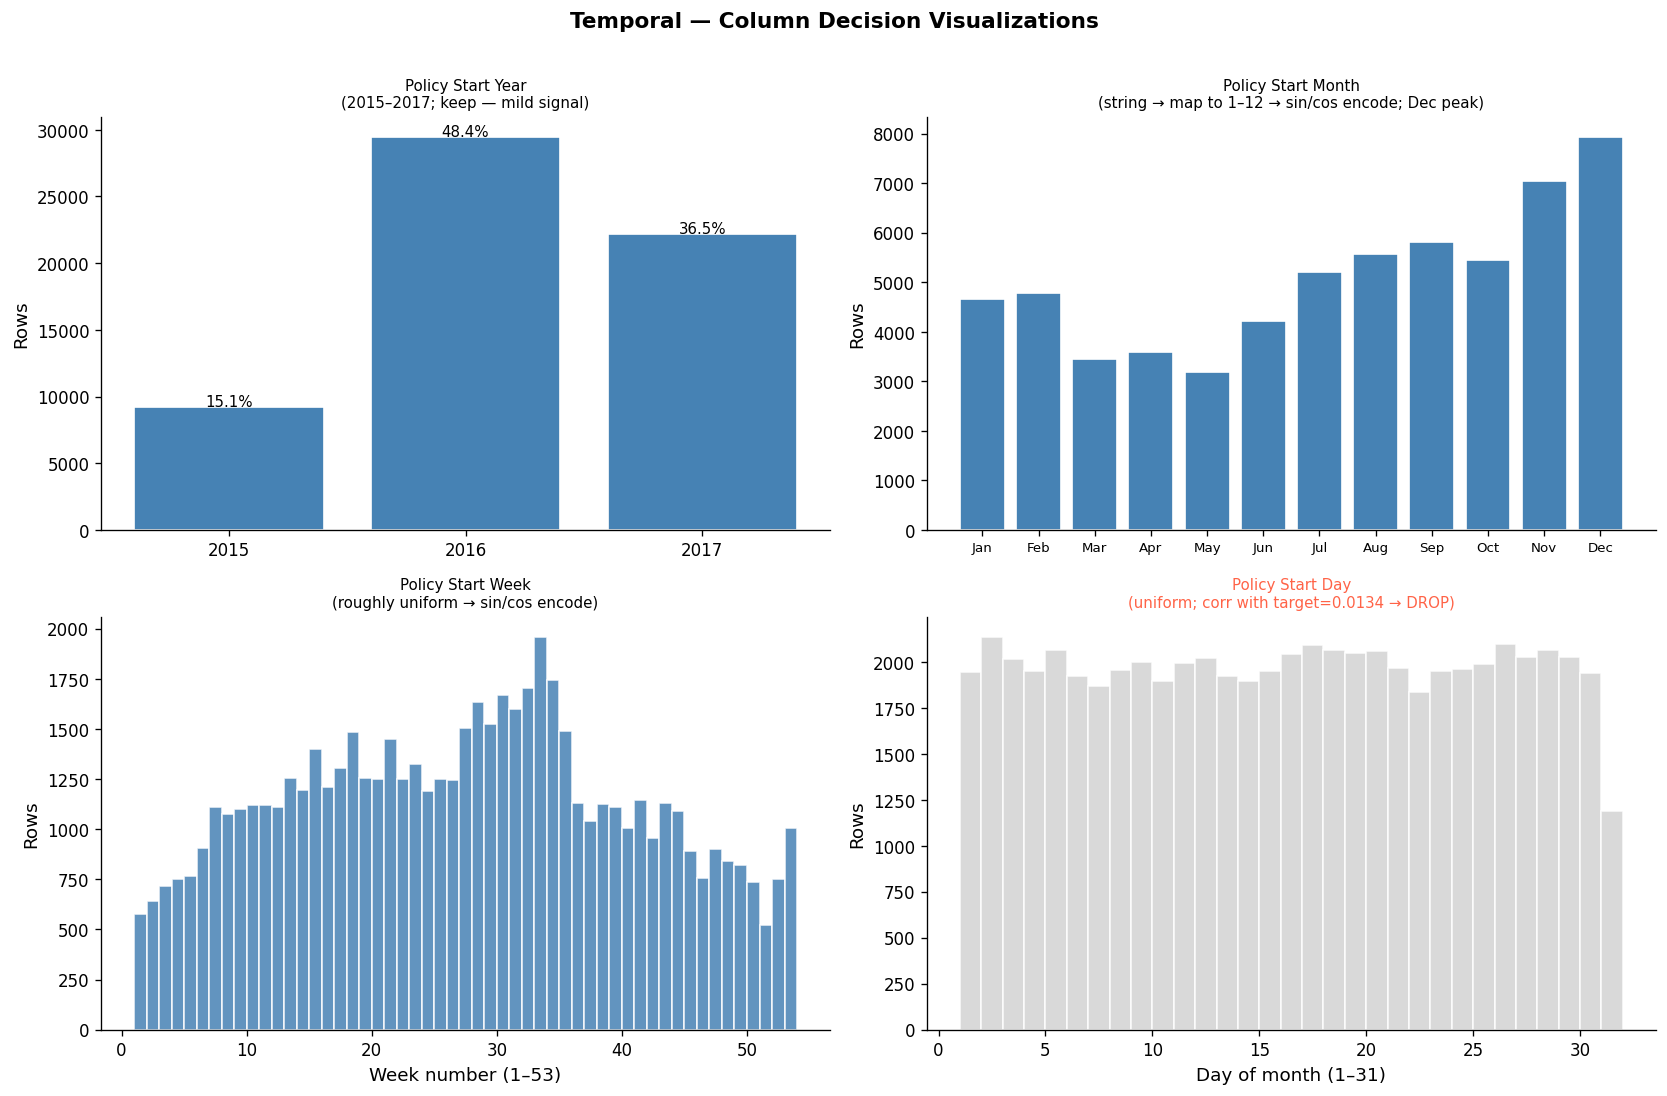

In [ ]:
MONTH_ORDER_LOCAL = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}
month_num = train['Policy_Start_Month'].map(MONTH_ORDER_LOCAL)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Year
vc = train['Policy_Start_Year'].value_counts().sort_index()
axes[0, 0].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
for i, v in enumerate(vc.values):
    axes[0, 0].text(i, v+50, f'{v/len(train)*100:.1f}%', ha='center', fontsize=9)
axes[0, 0].set_title('Policy Start Year\n(2015–2017; keep — mild signal)', fontsize=9)
axes[0, 0].set_ylabel('Rows')

# Month (bar, ordered Jan-Dec)
month_counts = month_num.value_counts().sort_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0, 1].bar(range(1, 13), [month_counts.get(m, 0) for m in range(1, 13)],
               color='steelblue', edgecolor='white')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_labels, fontsize=8)
axes[0, 1].set_title('Policy Start Month\n(string → map to 1–12 → sin/cos encode; Dec peak)', fontsize=9)
axes[0, 1].set_ylabel('Rows')

# Week
axes[1, 0].hist(train['Policy_Start_Week'], bins=53, range=(1, 54),
                color='steelblue', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Policy Start Week\n(roughly uniform → sin/cos encode)', fontsize=9)
axes[1, 0].set_xlabel('Week number (1–53)')
axes[1, 0].set_ylabel('Rows')

# Day — show near-zero correlation → DROP
day_target_corr = train[['Policy_Start_Day','Purchased_Coverage_Bundle']].corr().iloc[0,1]
axes[1, 1].hist(train['Policy_Start_Day'], bins=31, range=(1, 32),
                color='lightgrey', edgecolor='white', alpha=0.85)
axes[1, 1].set_title(f'Policy Start Day\n(uniform; corr with target={day_target_corr:.4f} → DROP)', fontsize=9, color='tomato')
axes[1, 1].set_xlabel('Day of month (1–31)')
axes[1, 1].set_ylabel('Rows')

plt.suptitle('Temporal — Column Decision Visualizations', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/col_temporal.png', bbox_inches='tight')
plt.show()

### 15.6 Feature Decision Summary

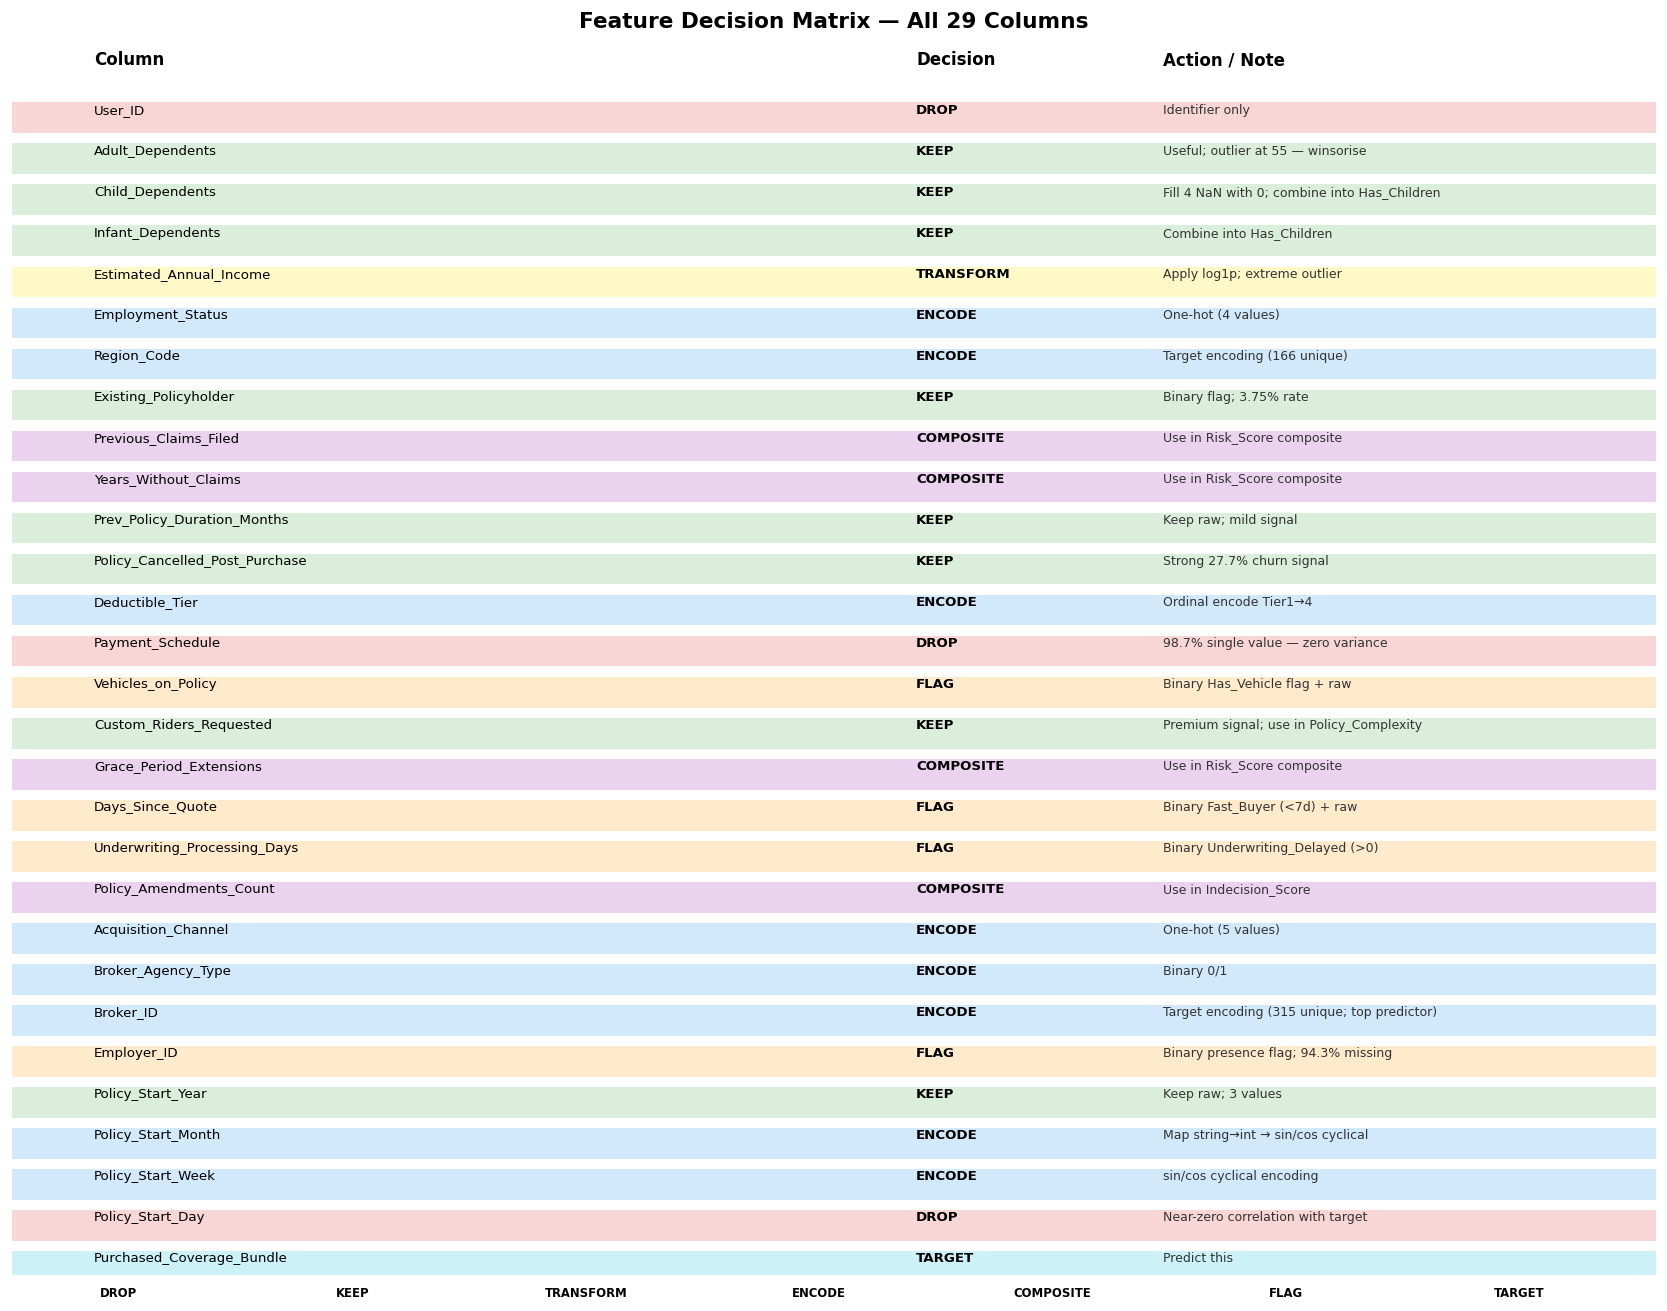

In [ ]:
decisions = {
    'User_ID':                        ('DROP',      'Identifier only'),
    'Adult_Dependents':               ('KEEP',      'Useful; outlier at 55 — winsorise'),
    'Child_Dependents':               ('KEEP',      'Fill 4 NaN with 0; combine into Has_Children'),
    'Infant_Dependents':              ('KEEP',      'Combine into Has_Children'),
    'Estimated_Annual_Income':        ('TRANSFORM', 'Apply log1p; extreme outlier'),
    'Employment_Status':              ('ENCODE',    'One-hot (4 values)'),
    'Region_Code':                    ('ENCODE',    'Target encoding (166 unique)'),
    'Existing_Policyholder':          ('KEEP',      'Binary flag; 3.75% rate'),
    'Previous_Claims_Filed':          ('COMPOSITE', 'Use in Risk_Score composite'),
    'Years_Without_Claims':           ('COMPOSITE', 'Use in Risk_Score composite'),
    'Prev_Policy_Duration_Months':    ('KEEP',      'Keep raw; mild signal'),
    'Policy_Cancelled_Post_Purchase': ('KEEP',      'Strong 27.7% churn signal'),
    'Deductible_Tier':                ('ENCODE',    'Ordinal encode Tier1→4'),
    'Payment_Schedule':               ('DROP',      '98.7% single value — zero variance'),
    'Vehicles_on_Policy':             ('FLAG',      'Binary Has_Vehicle flag + raw'),
    'Custom_Riders_Requested':        ('KEEP',      'Premium signal; use in Policy_Complexity'),
    'Grace_Period_Extensions':        ('COMPOSITE', 'Use in Risk_Score composite'),
    'Days_Since_Quote':               ('FLAG',      'Binary Fast_Buyer (<7d) + raw'),
    'Underwriting_Processing_Days':   ('FLAG',      'Binary Underwriting_Delayed (>0)'),
    'Policy_Amendments_Count':        ('COMPOSITE', 'Use in Indecision_Score'),
    'Acquisition_Channel':            ('ENCODE',    'One-hot (5 values)'),
    'Broker_Agency_Type':             ('ENCODE',    'Binary 0/1'),
    'Broker_ID':                      ('ENCODE',    'Target encoding (315 unique; top predictor)'),
    'Employer_ID':                    ('FLAG',      'Binary presence flag; 94.3% missing'),
    'Policy_Start_Year':              ('KEEP',      'Keep raw; 3 values'),
    'Policy_Start_Month':             ('ENCODE',    'Map string→int → sin/cos cyclical'),
    'Policy_Start_Week':              ('ENCODE',    'sin/cos cyclical encoding'),
    'Policy_Start_Day':               ('DROP',      'Near-zero correlation with target'),
    'Purchased_Coverage_Bundle':      ('TARGET',    'Predict this'),
}

color_map = {
    'DROP':      '#EF9A9A',
    'KEEP':      '#A5D6A7',
    'TRANSFORM': '#FFF176',
    'ENCODE':    '#90CAF9',
    'COMPOSITE': '#CE93D8',
    'FLAG':      '#FFCC80',
    'TARGET':    '#80DEEA',
}

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, len(decisions) + 1); ax.axis('off')

ax.text(0.5, len(decisions)+0.5, 'Column', fontsize=10, fontweight='bold', ha='left')
ax.text(5.5, len(decisions)+0.5, 'Decision', fontsize=10, fontweight='bold', ha='left')
ax.text(7.0, len(decisions)+0.5, 'Action / Note', fontsize=10, fontweight='bold', ha='left')

for i, (col, (decision, note)) in enumerate(reversed(list(decisions.items()))):
    y = i + 0.2
    bg = color_map.get(decision, 'white')
    ax.barh(y, 10, height=0.75, left=0, color=bg, alpha=0.4, zorder=1)
    ax.text(0.5, y+0.2, col, fontsize=8, va='center')
    ax.text(5.5, y+0.2, decision, fontsize=8, fontweight='bold', va='center')
    ax.text(7.0, y+0.2, note, fontsize=7.5, va='center', color='#333333')

# Legend
legend_items = list(color_map.items())
for j, (label, color) in enumerate(legend_items):
    ax.add_patch(plt.Rectangle((j*1.42, -0.8), 1.3, 0.55, color=color, alpha=0.7))
    ax.text(j*1.42 + 0.65, -0.52, label, fontsize=7, ha='center', fontweight='bold')

plt.title('Feature Decision Matrix — All 29 Columns', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('assets/col_decision_matrix.png', bbox_inches='tight')
plt.show()